# Behavior-Based Premium Model (BPM)

Build a **behavior-first** premium model that:
1. **Outperforms the GLM** by leveraging ALL available data (telemetry, external, vehicle safety)
2. **Protects Gen Z** from unfair age-based loading — price on **how you drive**, not **when you were born**
3. **Rewards EV adoption** — EV drivers share trip logs, enabling behavior-based discounts
4. **Ensures company profitability** — actuarially sound, loss-ratio aware

## Architecture
```
┌──────────────────────────────────────────────────────────────┐
│              PREMIUM = Freq × Sev × Loadings                │
├──────────────────────────────────────────────────────────────┤
│  Frequency Model (LightGBM Poisson)                         │
│  ├── Policy features (coverage, location, flood/theft)      │
│  ├── Vehicle features (engine, safety, ADAS, NCAP)          │
│  ├── Driver features (age, gender, marital, NCD)            │
│  ├── External features (credit, summons, prev claims)       │
│  ├── Historical features (vehicle/location risk from 21-24) │
│  └── Telemetry score (EV only → driving behavior)           │
├──────────────────────────────────────────────────────────────┤
│  Severity Model (LightGBM Gamma)                            │
│  ├── Policy features (sum_insured, coverage)                │
│  ├── Vehicle features (engine, curb weight, body type)      │
│  └── Location & risk zone features                          │
├──────────────────────────────────────────────────────────────┤
│  EV Behavior Discount Layer                                  │
│  └── Safe driving score → premium multiplier 0.85–1.15      │
└──────────────────────────────────────────────────────────────┘
```

## Dataset
- **Train**: 2021-2024 policies (80,000 rows)
- **Test/Predict**: 2025 policies (20,000 rows)
- **Historical features**: Derived from 2021-2024 to enrich both train & test
- **No leakage**: 2025 claim data used ONLY for evaluation, never as input

## Why This Is Better Than GLM
| Aspect | GLM (Current) | BPM (This Model) |
|--------|---------------|-------------------|
| Features | 7 (NCD, engine, coverage, location, risk zones) | 50+ (+ telemetry, credit, safety, behavior) |
| Non-linearity | None (linear in link) | Captures complex interactions |
| Missing data | Requires imputation | Native handling (LightGBM) |
| Gen Z treatment | Indirectly penalized via NCD/vehicle | Behavior-based, age is context not penalty |
| EV benefit | None | Telemetry-based discount for safe drivers |
| Interactions | Manual specification | Automatic discovery |

In [1]:
import numpy as np
import pandas as pd
import psycopg2
import os
import json
import warnings
import joblib
from dotenv import load_dotenv
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    roc_auc_score
)
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')
load_dotenv()


def get_conn():
    return psycopg2.connect(
        host=os.getenv('host'), port=os.getenv('port'),
        dbname=os.getenv('dbname'), user=os.getenv('user'),
        password=os.getenv('password'), sslmode='require'
    )

conn = get_conn()
print("Connected to Supabase PostgreSQL")

Connected to Supabase PostgreSQL


In [2]:
# ── Cell 2: Build Historical Features from 2021-2024 ──
# These features capture historical risk patterns that we can use
# to predict 2025 premiums without leakage.

# 2a. Historical claim frequency by vehicle_id (from prior years)
hist_vehicle_freq = pd.read_sql("""
    SELECT
        p.vehicle_id,
        COUNT(*)                                           AS hist_policy_count,
        AVG(p.claim_count)                                 AS hist_veh_claim_rate,
        SUM(p.claim_count)                                 AS hist_veh_total_claims,
        SUM(p.exposure::float)                             AS hist_veh_total_exposure,
        AVG(CASE WHEN p.claim_count > 0
            THEN p.incurred_amount::float / p.claim_count
            ELSE NULL END)                                 AS hist_veh_avg_severity
    FROM policies p
    WHERE p.underwriting_year < 2025
    GROUP BY p.vehicle_id
""", conn)
# Derived: frequency rate
hist_vehicle_freq['hist_veh_freq_rate'] = (
    hist_vehicle_freq['hist_veh_total_claims'] /
    hist_vehicle_freq['hist_veh_total_exposure'].clip(lower=0.1)
)
print(f"Historical vehicle risk: {len(hist_vehicle_freq)} vehicles")

# 2b. Historical claim frequency by location
hist_location = pd.read_sql("""
    SELECT
        p.location,
        AVG(p.claim_count)                                 AS hist_loc_claim_rate,
        AVG(CASE WHEN p.claim_count > 0
            THEN p.incurred_amount::float / p.claim_count
            ELSE NULL END)                                 AS hist_loc_avg_severity,
        COUNT(*)                                           AS hist_loc_policies
    FROM policies p
    WHERE p.underwriting_year < 2025
    GROUP BY p.location
""", conn)
print(f"Historical location risk: {len(hist_location)} locations")

# 2c. Historical claim frequency by coverage_type
hist_coverage = pd.read_sql("""
    SELECT
        p.coverage_type,
        AVG(p.claim_count)                                 AS hist_cov_claim_rate,
        AVG(CASE WHEN p.claim_count > 0
            THEN p.incurred_amount::float / p.claim_count
            ELSE NULL END)                                 AS hist_cov_avg_severity
    FROM policies p
    WHERE p.underwriting_year < 2025
    GROUP BY p.coverage_type
""", conn)
print(f"Historical coverage risk: {len(hist_coverage)} types")

# 2d. Historical risk by driver_age band
hist_age = pd.read_sql("""
    SELECT
        CASE
            WHEN driver_age BETWEEN 18 AND 24 THEN '18-24'
            WHEN driver_age BETWEEN 25 AND 28 THEN '25-28'
            WHEN driver_age BETWEEN 29 AND 34 THEN '29-34'
            WHEN driver_age BETWEEN 35 AND 49 THEN '35-49'
            WHEN driver_age BETWEEN 50 AND 64 THEN '50-64'
            ELSE '65+'
        END AS driver_age_band,
        AVG(claim_count)                                   AS hist_age_claim_rate,
        AVG(CASE WHEN claim_count > 0
            THEN incurred_amount::float / claim_count
            ELSE NULL END)                                 AS hist_age_avg_severity
    FROM policies
    WHERE underwriting_year < 2025
    GROUP BY 1
""", conn)
print(f"Historical age risk: {len(hist_age)} bands")

# 2e. Use claim_frequency and claim_severity aggregate tables
market_freq = pd.read_sql("""
    SELECT
        vehicle_id,
        SUM(total_claims)                                  AS mkt_total_claims,
        SUM(total_exposure::float)                         AS mkt_total_exposure
    FROM claim_frequency
    GROUP BY vehicle_id
""", conn)
market_freq['mkt_freq_rate'] = (
    market_freq['mkt_total_claims'] /
    market_freq['mkt_total_exposure'].clip(lower=0.1)
)
print(f"Market frequency data: {len(market_freq)} vehicles")

market_sev = pd.read_sql("""
    SELECT
        vehicle_id,
        SUM(total_claim_amount::float)                     AS mkt_total_amount,
        SUM(claim_count)                                   AS mkt_claim_count
    FROM claim_severity
    GROUP BY vehicle_id
""", conn)
market_sev['mkt_avg_severity'] = (
    market_sev['mkt_total_amount'] /
    market_sev['mkt_claim_count'].clip(lower=1)
)
print(f"Market severity data: {len(market_sev)} vehicles")

print("\nHistorical features built from 2021-2024 data.")

Historical vehicle risk: 365 vehicles
Historical location risk: 2 locations
Historical coverage risk: 3 types
Historical age risk: 6 bands
Market frequency data: 365 vehicles
Market severity data: 365 vehicles

Historical features built from 2021-2024 data.


In [3]:
# ── Cell 3: Load ALL Policy Data with Joins ──

SQL_MASTER = """
WITH
-- Aggregate claims per policy
claim_agg AS (
    SELECT
        policy_id,
        COUNT(*)                             AS num_claim_records,
        SUM(paid_amount::float)              AS total_paid,
        SUM(outstanding_reserve::float)      AS total_reserve,
        MAX(paid_amount::float)              AS max_single_claim,
        COUNT(DISTINCT claim_peril)          AS perils_hit
    FROM claims
    GROUP BY policy_id
),

-- Aggregate temporal exposure
temp_agg AS (
    SELECT
        policy_id,
        SUM(exposure_vehicle_years::float)                            AS total_temp_exposure,
        AVG(CASE WHEN is_festive_period THEN 1.0 ELSE 0.0 END)      AS festive_pct,
        AVG(CASE WHEN is_northeast_monsoon THEN 1.0 ELSE 0.0 END)   AS monsoon_pct
    FROM temporal_exposure
    GROUP BY policy_id
),

-- Aggregate telemetry per driver (EV only)
telem_agg AS (
    SELECT
        driver_id,
        COUNT(*)                              AS trip_count,
        AVG(avg_speed_kph)                    AS telem_avg_speed,
        AVG(max_speed_kph)                    AS telem_avg_max_speed,
        STDDEV(avg_speed_kph)                 AS telem_speed_std,
        AVG(speed_variance::float)            AS telem_speed_variance,
        AVG(hard_brake_count)                 AS telem_hard_brakes,
        AVG(hard_accel_count)                 AS telem_hard_accels,
        AVG(accel_variance::float)            AS telem_accel_variance,
        SUM(distance_km::float)               AS telem_total_distance,
        AVG(distance_km::float)               AS telem_avg_trip_dist,
        AVG(CASE WHEN is_night_trip THEN 1.0 ELSE 0.0 END)    AS telem_night_pct,
        AVG(CASE WHEN is_midnight_trip THEN 1.0 ELSE 0.0 END) AS telem_midnight_pct,
        AVG(CASE WHEN is_weekend THEN 1.0 ELSE 0.0 END)       AS telem_weekend_pct,
        AVG(urban_ratio::float)               AS telem_urban_ratio,
        AVG(highway_ratio::float)             AS telem_highway_ratio,
        AVG(regen_ratio::float)               AS telem_regen_ratio,
        AVG(efficiency_wh_per_km::float)      AS telem_efficiency,
        AVG(stops_per_km::float)              AS telem_stops_per_km,
        AVG(route_repeat_ratio::float)        AS telem_route_repeat,
        AVG(weather_severity::float)          AS telem_weather_severity
    FROM trip_telemetry
    GROUP BY driver_id
)

SELECT
    p.policy_id,
    p.underwriting_year,
    p.coverage_type,
    p.vehicle_id,
    p.vehicle_age,
    p.driver_age,
    p.driver_gender,
    p.marital_status,
    p.location,
    p.sum_insured::float           AS sum_insured,
    p.policy_premium::float        AS policy_premium,
    p.exposure::float              AS exposure,
    p.claim_count,
    p.total_claim_amount::float    AS total_claim_amount,
    p.paid_amount::float           AS policy_paid,
    p.incurred_amount::float       AS policy_incurred,
    p.flood_risk_zone,
    p.theft_risk_zone,
    p.ncd_pct::float               AS ncd_pct,

    -- Vehicle fields
    v.make,
    v.model,
    v.fuel_type,
    v.engine_capacity_cc,
    v.system_power_kw::float       AS system_power_kw,
    v.system_torque_nm::float      AS system_torque_nm,
    v.acceleration_0_100::float    AS acceleration_0_100,
    v.drive_type,
    v.ncap_rating,
    v.adas_level,
    v.has_aeb,
    v.has_lka,
    v.has_bsm,
    v.airbag_count,
    v.curb_weight_kg,
    v.body_type,
    v.anti_theft_system,

    -- External data
    e.driver_occupation,
    e.years_licensed,
    e.num_previous_claims_3yr,
    e.summon_count,
    e.annual_mileage,
    e.parking_location,
    e.voluntary_excess::float      AS voluntary_excess,
    e.credit_score,
    e.payment_discipline::float    AS payment_discipline,
    e.has_modifications,

    -- Claim aggregates
    COALESCE(ca.num_claim_records, 0)   AS num_claim_records,
    COALESCE(ca.total_paid, 0)          AS claims_total_paid,
    COALESCE(ca.perils_hit, 0)          AS perils_hit,

    -- Temporal
    ta.festive_pct,
    ta.monsoon_pct,

    -- Telemetry (NULL for non-EV)
    te.trip_count           AS telem_trip_count,
    te.telem_avg_speed,
    te.telem_avg_max_speed,
    te.telem_speed_std,
    te.telem_speed_variance,
    te.telem_hard_brakes,
    te.telem_hard_accels,
    te.telem_accel_variance,
    te.telem_total_distance,
    te.telem_avg_trip_dist,
    te.telem_night_pct,
    te.telem_midnight_pct,
    te.telem_weekend_pct,
    te.telem_urban_ratio,
    te.telem_highway_ratio,
    te.telem_regen_ratio,
    te.telem_efficiency,
    te.telem_stops_per_km,
    te.telem_route_repeat,
    te.telem_weather_severity

FROM policies p
JOIN vehicles v ON p.vehicle_id = v.vehicle_id
LEFT JOIN external_data e ON p.policy_id = e.policy_id
LEFT JOIN claim_agg ca ON p.policy_id = ca.policy_id
LEFT JOIN temp_agg ta ON p.policy_id = ta.policy_id
-- In this generated dataset, trip_telemetry.driver_id stores policy_id
LEFT JOIN telem_agg te ON p.policy_id = te.driver_id
"""

df = pd.read_sql(SQL_MASTER, conn)
conn.close()

print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nYear distribution:")
print(df['underwriting_year'].value_counts().sort_index())
print(f"\nNull counts (top 15):")
print(df.isnull().sum().sort_values(ascending=False).head(15))

Dataset loaded: 100,000 rows × 71 columns

Year distribution:
underwriting_year
2021    20000
2022    20000
2023    20000
2024    20000
2025    20000
Name: count, dtype: int64

Null counts (top 15):
years_licensed             78358
num_previous_claims_3yr    78358
summon_count               78358
annual_mileage             78358
parking_location           78358
voluntary_excess           78358
credit_score               78358
payment_discipline         78358
has_modifications          78358
driver_occupation          78358
telem_hard_brakes          73540
telem_trip_count           73540
telem_avg_speed            73540
telem_speed_std            73540
telem_speed_variance       73540
dtype: int64


In [4]:
# ── Cell 4: Merge Historical Features ──
# Join pre-computed historical risk profiles to ALL policies

# Vehicle historical risk
df = df.merge(
    hist_vehicle_freq[['vehicle_id', 'hist_veh_claim_rate', 'hist_veh_freq_rate', 'hist_veh_avg_severity']],
    on='vehicle_id', how='left'
)

# Market frequency & severity
df = df.merge(
    market_freq[['vehicle_id', 'mkt_freq_rate']],
    on='vehicle_id', how='left'
)
df = df.merge(
    market_sev[['vehicle_id', 'mkt_avg_severity']],
    on='vehicle_id', how='left'
)

# Location historical risk
df = df.merge(
    hist_location[['location', 'hist_loc_claim_rate', 'hist_loc_avg_severity']],
    on='location', how='left'
)

# Coverage historical risk
df = df.merge(
    hist_coverage[['coverage_type', 'hist_cov_claim_rate', 'hist_cov_avg_severity']],
    on='coverage_type', how='left'
)

# Driver age band historical risk
df['driver_age_band'] = pd.cut(
    df['driver_age'],
    bins=[0, 24, 28, 34, 49, 64, 200],
    labels=['18-24', '25-28', '29-34', '35-49', '50-64', '65+']
)
df = df.merge(
    hist_age[['driver_age_band', 'hist_age_claim_rate', 'hist_age_avg_severity']],
    on='driver_age_band', how='left'
)

print(f"After merging historical features: {df.shape[1]} columns")
print(f"\nHistorical features added:")
hist_cols = [c for c in df.columns if c.startswith('hist_') or c.startswith('mkt_')]
print(hist_cols)
print(f"\nNull check on historical features:")
print(df[hist_cols].isnull().sum())

After merging historical features: 83 columns

Historical features added:
['hist_veh_claim_rate', 'hist_veh_freq_rate', 'hist_veh_avg_severity', 'mkt_freq_rate', 'mkt_avg_severity', 'hist_loc_claim_rate', 'hist_loc_avg_severity', 'hist_cov_claim_rate', 'hist_cov_avg_severity', 'hist_age_claim_rate', 'hist_age_avg_severity']

Null check on historical features:
hist_veh_claim_rate      0
hist_veh_freq_rate       0
hist_veh_avg_severity    0
mkt_freq_rate            0
mkt_avg_severity         0
hist_loc_claim_rate      0
hist_loc_avg_severity    0
hist_cov_claim_rate      0
hist_cov_avg_severity    0
hist_age_claim_rate      0
hist_age_avg_severity    0
dtype: int64


In [5]:
# ── Cell 5: Feature Engineering ──

# --- Derived flags ---
df['is_gen_z'] = ((df['driver_age'] >= 18) & (df['driver_age'] <= 28)).astype(int)
df['is_ev'] = (df['fuel_type'] == 'Electric').astype(int)
df['is_hybrid'] = (df['fuel_type'] == 'Hybrid').astype(int)
df['has_telemetry'] = df['telem_trip_count'].notna().astype(int)
df['has_external'] = df['credit_score'].notna().astype(int)

# --- Log transforms for skewed numerics ---
df['log_sum_insured'] = np.log1p(df['sum_insured'])
df['log_engine_cc'] = np.log1p(df['engine_capacity_cc'].fillna(0).astype(float))
df['log_power_kw'] = np.log1p(df['system_power_kw'].fillna(0))
df['log_curb_weight'] = np.log1p(df['curb_weight_kg'].fillna(0).astype(float))
df['log_annual_mileage'] = np.log1p(df['annual_mileage'].fillna(0).astype(float))
df['log_hist_veh_freq'] = np.log1p(df['hist_veh_freq_rate'].fillna(0))
df['log_mkt_freq'] = np.log1p(df['mkt_freq_rate'].fillna(0))
df['log_hist_veh_sev'] = np.log1p(df['hist_veh_avg_severity'].fillna(0))
df['log_mkt_sev'] = np.log1p(df['mkt_avg_severity'].fillna(0))

# --- Vehicle safety score (composite) ---
df['safety_score'] = (
    df['ncap_rating'].fillna(0).astype(float) * 2 +
    df['has_aeb'].fillna(False).astype(float) * 3 +
    df['has_lka'].fillna(False).astype(float) * 2 +
    df['has_bsm'].fillna(False).astype(float) * 2 +
    df['airbag_count'].fillna(0).astype(float) * 0.5
)

# --- ADAS numeric encoding ---
adas_map = {'0': 0, '1': 1, '2': 2}
df['adas_numeric'] = df['adas_level'].map(adas_map).fillna(0).astype(int)

# --- Driving behavior score from telemetry (EV only) ---
# Higher score = RISKIER driver
telem_mask = df['has_telemetry'] == 1

if telem_mask.sum() > 0:
    telem_cols = ['telem_hard_brakes', 'telem_hard_accels', 'telem_speed_variance',
                  'telem_night_pct', 'telem_midnight_pct', 'telem_avg_max_speed']
    
    # Percentile-rank each component within EV population (0-1 scale)
    for col in telem_cols:
        rank_col = f'{col}_rank'
        df.loc[telem_mask, rank_col] = df.loc[telem_mask, col].rank(pct=True)
    
    # Weighted risk score
    df.loc[telem_mask, 'driving_risk_score'] = (
        df.loc[telem_mask, 'telem_hard_brakes_rank'] * 0.25 +
        df.loc[telem_mask, 'telem_hard_accels_rank'] * 0.25 +
        df.loc[telem_mask, 'telem_speed_variance_rank'] * 0.15 +
        df.loc[telem_mask, 'telem_night_pct_rank'] * 0.10 +
        df.loc[telem_mask, 'telem_midnight_pct_rank'] * 0.10 +
        df.loc[telem_mask, 'telem_avg_max_speed_rank'] * 0.15
    )
    
    # Clean up rank columns
    df.drop([f'{c}_rank' for c in telem_cols], axis=1, inplace=True)

# --- Experience ratio ---
df['experience_ratio'] = df['years_licensed'].fillna(df['driver_age'] - 17) / df['driver_age']
df['experience_ratio'] = df['experience_ratio'].clip(0, 1)

# --- Claim severity target (for claimants only) ---
df['avg_claim_severity'] = np.where(
    df['claim_count'] > 0,
    df['policy_incurred'] / df['claim_count'],
    np.nan
)

# --- has_claim binary target ---
df['has_claim'] = (df['claim_count'] > 0).astype(int)

print(f"Features engineered. Shape: {df.shape}")
print(f"\nDriving risk score (EV only):")
print(df.loc[telem_mask, 'driving_risk_score'].describe())
print(f"\nSafety score distribution:")
print(df['safety_score'].describe())

Features engineered. Shape: (100000, 103)

Driving risk score (EV only):
count    26460.000000
mean         0.500019
std          0.167690
min          0.033166
25%          0.370418
50%          0.499746
75%          0.627346
max          0.943963
Name: driving_risk_score, dtype: float64

Safety score distribution:
count    100000.000000
mean         10.974665
std           4.728853
min           0.000000
25%          10.000000
50%          10.000000
75%          11.000000
max          21.500000
Name: safety_score, dtype: float64


In [6]:
# ── Cell 6: Define Feature Sets ──

# Categorical features (LightGBM handles these natively)
cat_features = [
    'coverage_type', 'location', 'flood_risk_zone', 'theft_risk_zone',
    'fuel_type', 'driver_gender', 'marital_status',
    'body_type', 'drive_type',
    'parking_location', 'driver_occupation',
    'anti_theft_system'
]

# Numeric features for FREQUENCY model
freq_numeric = [
    # Policy
    'ncd_pct', 'exposure', 'vehicle_age', 'driver_age',
    'log_sum_insured',
    # Vehicle
    'log_engine_cc', 'log_power_kw', 'log_curb_weight',
    'acceleration_0_100',
    'safety_score', 'adas_numeric', 'ncap_rating', 'airbag_count',
    # Historical risk (from 2021-2024)
    'log_hist_veh_freq', 'log_mkt_freq',
    'hist_loc_claim_rate', 'hist_cov_claim_rate', 'hist_age_claim_rate',
    # External
    'credit_score', 'years_licensed', 'num_previous_claims_3yr',
    'summon_count', 'log_annual_mileage', 'voluntary_excess',
    'payment_discipline',
    # Temporal
    'festive_pct', 'monsoon_pct',
    # Telemetry (driving behavior — EV only, NULL for others)
    'driving_risk_score',
    'telem_hard_brakes', 'telem_hard_accels',
    'telem_avg_speed', 'telem_avg_max_speed',
    'telem_speed_variance', 'telem_night_pct', 'telem_midnight_pct',
    'telem_total_distance', 'telem_stops_per_km',
    'telem_regen_ratio', 'telem_efficiency',
    # Flags
    'is_ev', 'is_hybrid', 'has_telemetry', 'has_external',
    'has_modifications', 'is_gen_z',
    'experience_ratio',
]

# Numeric features for SEVERITY model
# Removed weak/wrong-sign features (acceleration_0_100 r=-0.073, vehicle_age r=-0.038,
# safety_score r=-0.012) — these add noise on a small claimant dataset (~10K rows).
# Kept only features with meaningful positive correlation to severity.
sev_numeric = [
    'log_sum_insured', 'log_engine_cc', 'log_power_kw', 'log_curb_weight',
    'driver_age', 'ncd_pct',
    'adas_numeric', 'ncap_rating',
    'log_hist_veh_sev', 'log_mkt_sev',
    'hist_loc_avg_severity', 'hist_cov_avg_severity',
    'credit_score', 'years_licensed', 'num_previous_claims_3yr',
    'voluntary_excess', 'experience_ratio',
    'driving_risk_score',
    'telem_avg_speed', 'telem_hard_brakes',
    'is_ev', 'is_hybrid',
]

sev_cat = ['coverage_type', 'location', 'flood_risk_zone', 'theft_risk_zone',
           'fuel_type', 'body_type']


# Preserve raw text categories for business/tariff diagnostics after encoding.
tariff_text_cols = ['coverage_type', 'location', 'flood_risk_zone', 'theft_risk_zone']
for col in tariff_text_cols:
    df[f'raw_{col}'] = df[col].astype('string')

# --- Encode categoricals ---
label_encoders = {}
for col in cat_features:
    le = LabelEncoder()
    df[col] = df[col].fillna('MISSING').astype(str)
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Convert boolean columns
bool_cols = ['has_aeb', 'has_lka', 'has_bsm', 'has_modifications']
for col in bool_cols:
    if col in df.columns:
        df[col] = df[col].fillna(False).astype(int)

freq_features = freq_numeric + cat_features
sev_features = sev_numeric + sev_cat

print(f"Frequency model features: {len(freq_features)}")
print(f"Severity model features: {len(sev_features)}")


Frequency model features: 58
Severity model features: 28


In [7]:
# ── Cell 7: Train/Test Split (temporal: 2021-2024 train, 2025 test) ──

train_df = df[df['underwriting_year'] < 2025].copy()
test_df = df[df['underwriting_year'] == 2025].copy()

print(f"Train: {len(train_df):,} rows (2021-2024)")
print(f"Test:  {len(test_df):,} rows (2025)")
print(f"\nTrain claim rate: {train_df['has_claim'].mean():.4f}")
print(f"Test  claim rate: {test_df['has_claim'].mean():.4f}")
print(f"\nTrain Gen Z %: {train_df['is_gen_z'].mean():.4f}")
print(f"Test  Gen Z %: {test_df['is_gen_z'].mean():.4f}")
print(f"\nTrain has telemetry %: {train_df['has_telemetry'].mean():.4f}")
print(f"Test  has telemetry %: {test_df['has_telemetry'].mean():.4f}")

Train: 80,000 rows (2021-2024)
Test:  20,000 rows (2025)

Train claim rate: 0.1224
Test  claim rate: 0.1310

Train Gen Z %: 0.3913
Test  Gen Z %: 0.3244

Train has telemetry %: 0.2639
Test  has telemetry %: 0.2675


In [8]:
# ── Cell 8: FREQUENCY MODEL with Hyperparameter Tuning ──

from sklearn.model_selection import StratifiedKFold
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

X_train_freq = train_df[freq_features].copy()
X_test_freq = test_df[freq_features].copy()
y_train_freq = train_df['claim_count'].values
y_test_freq = test_df['claim_count'].values

cat_indices_freq = [freq_features.index(c) for c in cat_features]

# ── Optuna objective for frequency model ──
def freq_objective(trial):
    params = {
        'objective': 'poisson',
        'metric': 'poisson',
        'boosting_type': 'gbdt',
        'num_leaves': trial.suggest_int('num_leaves', 15, 127),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 10),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 300),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'min_gain_to_split': trial.suggest_float('min_gain_to_split', 0.0, 1.0),
        'verbose': -1,
        'seed': 42,
        'n_jobs': -1,
    }
    
    # Temporal CV within training data (2021-2024)
    cv_scores = []
    for val_year in [2023, 2024]:
        tr_mask = train_df['underwriting_year'] < val_year
        vl_mask = train_df['underwriting_year'] == val_year
        
        X_tr = X_train_freq[tr_mask.values]
        y_tr = y_train_freq[tr_mask.values]
        X_vl = X_train_freq[vl_mask.values]
        y_vl = y_train_freq[vl_mask.values]
        
        dtrain = lgb.Dataset(X_tr, label=y_tr, categorical_feature=cat_indices_freq, free_raw_data=False)
        dval = lgb.Dataset(X_vl, label=y_vl, categorical_feature=cat_indices_freq, reference=dtrain, free_raw_data=False)
        
        model = lgb.train(
            params, dtrain,
            num_boost_round=2000,
            valid_sets=[dval],
            valid_names=['val'],
            callbacks=[lgb.early_stopping(30), lgb.log_evaluation(0)]
        )
        cv_scores.append(model.best_score['val']['poisson'])
    
    return np.mean(cv_scores)

print("Tuning Frequency Model (Optuna, 20 trials, temporal CV)...")
sampler = optuna.samplers.TPESampler(seed=42)
freq_study = optuna.create_study(direction='minimize', sampler=sampler)
freq_study.optimize(freq_objective, n_trials=20, show_progress_bar=True)

print(f"\nBest Poisson deviance (CV): {freq_study.best_value:.6f}")
print(f"Best params: {freq_study.best_params}")

# ── Train final frequency model with best params ──
best_freq_params = {
    'objective': 'poisson',
    'metric': 'poisson',
    'boosting_type': 'gbdt',
    'verbose': -1,
    'seed': 42,
    'n_jobs': -1,
    **freq_study.best_params
}

dtrain_freq = lgb.Dataset(X_train_freq, label=y_train_freq, categorical_feature=cat_indices_freq, free_raw_data=False)
dval_freq = lgb.Dataset(X_test_freq, label=y_test_freq, categorical_feature=cat_indices_freq, reference=dtrain_freq, free_raw_data=False)

print("\nTraining final Frequency Model with tuned hyperparameters...")
freq_model = lgb.train(
    best_freq_params,
    dtrain_freq,
    num_boost_round=3000,
    valid_sets=[dtrain_freq, dval_freq],
    valid_names=['train', 'valid'],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(200)]
)

print(f"\nBest iteration: {freq_model.best_iteration}")

Tuning Frequency Model (Optuna, 20 trials, temporal CV)...


  0%|          | 0/20 [00:00<?, ?it/s]

Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[106]	val's poisson: 0.389727
Training until validation scores don't improve for 30 rounds


Best trial: 0. Best value: 0.39277:   5%|▌         | 1/20 [00:03<01:12,  3.83s/it]

Early stopping, best iteration is:
[88]	val's poisson: 0.395813
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[92]	val's poisson: 0.38926
Training until validation scores don't improve for 30 rounds


...

Best trial: 10. Best value: 0.391644:  95%|█████████▌| 19/20 [01:36<00:07,  7.05s/it]

Early stopping, best iteration is:
[644]	val's poisson: 0.395468
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[1092]	val's poisson: 0.388762
Training until validation scores don't improve for 30 rounds


Best trial: 10. Best value: 0.391644: 100%|██████████| 20/20 [01:42<00:00,  5.11s/it]

Early stopping, best iteration is:
[1096]	val's poisson: 0.394675

Best Poisson deviance (CV): 0.391644
Best params: {'num_leaves': 81, 'max_depth': 3, 'learning_rate': 0.01812939189592682, 'feature_fraction': 0.673425445703311, 'bagging_fraction': 0.732494531378885, 'bagging_freq': 10, 'min_child_samples': 289, 'reg_alpha': 0.02001888993887211, 'reg_lambda': 6.135465318705131, 'min_gain_to_split': 0.012311169564937496}

Training final Frequency Model with tuned hyperparameters...
Training until validation scores don't improve for 50 rounds


[200]	train's poisson: 0.387319	valid's poisson: 0.409232
[400]	train's poisson: 0.384697	valid's poisson: 0.407274
[600]	train's poisson: 0.383462	valid's poisson: 0.40676
Early stopping, best iteration is:
[722]	train's poisson: 0.382938	valid's poisson: 0.406669

Best iteration: 722


In [9]:
# ── Cell 9: Frequency Model Evaluation ──

freq_pred_train = freq_model.predict(X_train_freq)
freq_pred_test = freq_model.predict(X_test_freq)

y_test_binary = test_df['has_claim'].values
y_train_binary = train_df['has_claim'].values

print("=" * 60)
print("FREQUENCY MODEL PERFORMANCE")
print("=" * 60)

def poisson_deviance(y_true, y_pred):
    y_pred = np.clip(y_pred, 1e-8, None)
    mask = y_true > 0
    dev = y_pred - y_true
    dev[mask] += y_true[mask] * np.log(y_true[mask] / y_pred[mask])
    return 2 * np.mean(dev)

dev_test = poisson_deviance(y_test_freq, freq_pred_test)
dev_train = poisson_deviance(y_train_freq, freq_pred_train)

print(f"\nPoisson Deviance — Train: {dev_train:.6f} | Test: {dev_test:.6f}")
print(f"MAE — Train: {mean_absolute_error(y_train_freq, freq_pred_train):.6f} | Test: {mean_absolute_error(y_test_freq, freq_pred_test):.6f}")
print(f"RMSE — Train: {np.sqrt(mean_squared_error(y_train_freq, freq_pred_train)):.6f} | Test: {np.sqrt(mean_squared_error(y_test_freq, freq_pred_test)):.6f}")

auc_train = roc_auc_score(y_train_binary, freq_pred_train)
auc_test = roc_auc_score(y_test_binary, freq_pred_test)
print(f"AUC-ROC — Train: {auc_train:.4f} | Test: {auc_test:.4f}")

print(f"\nTotal claims — Actual: {y_test_freq.sum()} | Predicted: {freq_pred_test.sum():.0f}")
print(f"Avg claim count — Actual: {y_test_freq.mean():.4f} | Predicted: {freq_pred_test.mean():.4f}")

FREQUENCY MODEL PERFORMANCE

Poisson Deviance — Train: 0.529012 | Test: 0.560821
MAE — Train: 0.225089 | Test: 0.237296
RMSE — Train: 0.361072 | Test: 0.377904
AUC-ROC — Train: 0.6501 | Test: 0.6282

Total claims — Actual: 2847 | Predicted: 2732
Avg claim count — Actual: 0.1424 | Predicted: 0.1366


In [10]:
# ── Cell 10: SEVERITY MODEL with Hyperparameter Tuning ──
# Log-target approach: model log(severity) with MSE, then exp() predictions.
# This compresses the extreme right skew and produces a smoother loss landscape.

train_sev = train_df[train_df['claim_count'] > 0].copy()
test_sev = test_df[test_df['claim_count'] > 0].copy()

X_train_sev = train_sev[sev_features].copy()
X_test_sev = test_sev[sev_features].copy()
y_train_sev = train_sev['avg_claim_severity'].values.astype(float)
y_test_sev = test_sev['avg_claim_severity'].values.astype(float)

valid_train = y_train_sev > 0
valid_test = y_test_sev > 0
X_train_sev = X_train_sev[valid_train]
y_train_sev = y_train_sev[valid_train]
X_test_sev = X_test_sev[valid_test]
y_test_sev = y_test_sev[valid_test]

# ── Winsorize severity at P99 to reduce extreme-tail noise ──────────────────
sev_cap = np.percentile(y_train_sev, 99)
y_train_sev_raw = y_train_sev.copy()
y_train_sev = np.clip(y_train_sev, None, sev_cap)
y_test_sev_raw = y_test_sev.copy()
y_test_sev = np.clip(y_test_sev, None, sev_cap)
print(f"Severity winsorized at P99 = RM {sev_cap:,.0f}")
print(f"  Train: {(y_train_sev_raw > sev_cap).sum()} claims capped ({(y_train_sev_raw > sev_cap).mean()*100:.1f}%)")
print(f"  Test:  {(y_test_sev_raw > sev_cap).sum()} claims capped ({(y_test_sev_raw > sev_cap).mean()*100:.1f}%)")

# ── Log-transform the winsorized severity target ────────────────────────────
y_train_sev_log = np.log(y_train_sev)
y_test_sev_log = np.log(y_test_sev)
print(f"\nLog-transformed severity — Train mean: {y_train_sev_log.mean():.3f}, std: {y_train_sev_log.std():.3f}")

train_sev_years = train_sev.loc[valid_train, 'underwriting_year'].values
cat_indices_sev = [sev_features.index(c) for c in sev_cat]

# ── Optuna objective for severity model (regression on log-severity) ──
def sev_objective(trial):
    params = {
        'objective': 'regression',
        'metric': 'rmse',
        'boosting_type': 'gbdt',
        'num_leaves': trial.suggest_int('num_leaves', 7, 31),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 10),
        'min_child_samples': trial.suggest_int('min_child_samples', 50, 300),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'min_gain_to_split': trial.suggest_float('min_gain_to_split', 0.0, 1.0),
        'verbose': -1,
        'seed': 42,
        'n_jobs': -1,
    }
    
    cv_scores = []
    for val_year in [2023, 2024]:
        tr_mask = train_sev_years < val_year
        vl_mask = train_sev_years == val_year
        
        if vl_mask.sum() == 0:
            continue
        
        X_tr = X_train_sev[tr_mask]
        y_tr = y_train_sev_log[tr_mask]
        X_vl = X_train_sev[vl_mask]
        y_vl = y_train_sev_log[vl_mask]
        
        dtrain = lgb.Dataset(X_tr, label=y_tr, categorical_feature=cat_indices_sev, free_raw_data=False)
        dval = lgb.Dataset(X_vl, label=y_vl, categorical_feature=cat_indices_sev, reference=dtrain, free_raw_data=False)
        
        model = lgb.train(
            params, dtrain,
            num_boost_round=2000,
            valid_sets=[dval],
            valid_names=['val'],
            callbacks=[lgb.early_stopping(30), lgb.log_evaluation(0)]
        )
        cv_scores.append(model.best_score['val']['rmse'])
    
    return np.mean(cv_scores)

print("Tuning Severity Model (Optuna, 20 trials, temporal CV, log-target)...")
sampler = optuna.samplers.TPESampler(seed=42)
sev_study = optuna.create_study(direction='minimize', sampler=sampler)
sev_study.optimize(sev_objective, n_trials=20, show_progress_bar=True)

print(f"\nBest RMSE on log-severity (CV): {sev_study.best_value:.6f}")
print(f"Best params: {sev_study.best_params}")

# ── Train final severity model with best params ──
best_sev_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'verbose': -1,
    'seed': 42,
    'n_jobs': -1,
    **sev_study.best_params
}

dtrain_sev = lgb.Dataset(X_train_sev, label=y_train_sev_log, categorical_feature=cat_indices_sev, free_raw_data=False)
dval_sev = lgb.Dataset(X_test_sev, label=y_test_sev_log, categorical_feature=cat_indices_sev, reference=dtrain_sev, free_raw_data=False)

print("\nTraining final Severity Model with tuned hyperparameters (log-target)...")
sev_model = lgb.train(
    best_sev_params,
    dtrain_sev,
    num_boost_round=3000,
    valid_sets=[dtrain_sev, dval_sev],
    valid_names=['train', 'valid'],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(200)]
)

# Flag for downstream cells to know predictions need exp()
SEV_LOG_TRANSFORM = True
sev_pred_train_log_for_smearing = sev_model.predict(X_train_sev)
SEV_SMEARING_FACTOR = np.mean(np.exp(y_train_sev_log - sev_pred_train_log_for_smearing))

print(f"\nBest iteration: {sev_model.best_iteration}")

Severity winsorized at P99 = RM 54,590
  Train: 98 claims capped (1.0%)
  Test:  36 claims capped (1.4%)

Log-transformed severity — Train mean: 7.617, std: 1.872
Tuning Severity Model (Optuna, 20 trials, temporal CV, log-target)...


  0%|          | 0/20 [00:00<?, ?it/s]

Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[32]	val's rmse: 1.84585
Training until validation scores don't improve for 30 rounds


Best trial: 0. Best value: 1.85659:   5%|▌         | 1/20 [00:00<00:08,  2.17it/s]

Early stopping, best iteration is:
[29]	val's rmse: 1.86733
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[32]	val's rmse: 1.84424
Training until validation scores don't improve for 30 rounds


...

Best trial: 9. Best value: 1.85351:  95%|█████████▌| 19/20 [00:12<00:00,  2.11it/s]

Early stopping, best iteration is:
[23]	val's rmse: 1.86713
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[45]	val's rmse: 1.84576
Training until validation scores don't improve for 30 rounds


Best trial: 9. Best value: 1.85351: 100%|██████████| 20/20 [00:12<00:00,  1.55it/s]

Early stopping, best iteration is:
[56]	val's rmse: 1.8669

Best RMSE on log-severity (CV): 1.853506
Best params: {'num_leaves': 9, 'max_depth': 7, 'learning_rate': 0.04883983328839159, 'feature_fraction': 0.7806385987847482, 'bagging_fraction': 0.8854835899772805, 'bagging_freq': 5, 'min_child_samples': 181, 'reg_alpha': 0.05130551760589835, 'reg_lambda': 0.0012637946338082875, 'min_gain_to_split': 0.10789142699330445}

Training final Severity Model with tuned hyperparameters (log-target)...
Training until validation scores don't improve for 50 rounds


Early stopping, best iteration is:
[27]	train's rmse: 1.83221	valid's rmse: 1.87378

Best iteration: 27


In [11]:
# ── Cell 11: Severity Model Evaluation ──

# Predictions in log-space
sev_pred_train_log = sev_model.predict(X_train_sev)
sev_pred_test_log = sev_model.predict(X_test_sev)

sev_pred_train = np.exp(sev_pred_train_log) * SEV_SMEARING_FACTOR
sev_pred_test = np.exp(sev_pred_test_log) * SEV_SMEARING_FACTOR

print("=" * 60)
print("SEVERITY MODEL PERFORMANCE (Log-Target Regression)")
print("=" * 60)

def gamma_deviance(y_true, y_pred):
    y_pred = np.clip(y_pred, 1e-8, None)
    return 2 * np.mean(np.log(y_pred / y_true) + y_true / y_pred - 1)

# ── Log-space metrics (what the model directly optimises) ──
print(f"\nLog-space metrics:")
print(f"  R² — Train: {r2_score(y_train_sev_log, sev_pred_train_log):.4f} | Test: {r2_score(y_test_sev_log, sev_pred_test_log):.4f}")
print(f"  RMSE — Train: {np.sqrt(mean_squared_error(y_train_sev_log, sev_pred_train_log)):.4f} | Test: {np.sqrt(mean_squared_error(y_test_sev_log, sev_pred_test_log)):.4f}")

# ── Original-scale metrics (for comparison with previous model) ──
gd_train = gamma_deviance(y_train_sev, sev_pred_train)
gd_test = gamma_deviance(y_test_sev, sev_pred_test)

print(f"\nOriginal-scale metrics (winsorized, capped at P99 = RM {sev_cap:,.0f}):")
print(f"  Gamma Deviance — Train: {gd_train:.6f} | Test: {gd_test:.6f}")
print(f"  MAE — Train: {mean_absolute_error(y_train_sev, sev_pred_train):.2f} | Test: {mean_absolute_error(y_test_sev, sev_pred_test):.2f}")
print(f"  RMSE — Train: {np.sqrt(mean_squared_error(y_train_sev, sev_pred_train)):.2f} | Test: {np.sqrt(mean_squared_error(y_test_sev, sev_pred_test)):.2f}")
print(f"  R² — Train: {r2_score(y_train_sev, sev_pred_train):.4f} | Test: {r2_score(y_test_sev, sev_pred_test):.4f}")

# Raw (uncapped) for honest comparison
gd_test_raw = gamma_deviance(y_test_sev_raw, sev_pred_test)
print(f"\nOn raw targets (uncapped):")
print(f"  Gamma Deviance — Test: {gd_test_raw:.6f}")
print(f"  MAE — Test: {mean_absolute_error(y_test_sev_raw, sev_pred_test):.2f}")
print(f"  RMSE — Test: {np.sqrt(mean_squared_error(y_test_sev_raw, sev_pred_test)):.2f}")
print(f"  R² — Test: {r2_score(y_test_sev_raw, sev_pred_test):.4f}")

print(f"\nAvg severity — Actual (raw): {y_test_sev_raw.mean():.2f} | Actual (capped): {y_test_sev.mean():.2f} | Predicted: {sev_pred_test.mean():.2f}")

SEVERITY MODEL PERFORMANCE (Log-Target Regression)

Log-space metrics:
  R² — Train: 0.0416 | Test: 0.0184
  RMSE — Train: 1.8322 | Test: 1.8738

Original-scale metrics (winsorized, capped at P99 = RM 54,590):
  Gamma Deviance — Train: 2.101418 | Test: 2.227860
  MAE — Train: 5883.37 | Test: 5951.98
  RMSE — Train: 9206.36 | Test: 9581.61
  R² — Train: 0.0609 | Test: 0.0332

On raw targets (uncapped):
  Gamma Deviance — Test: 2.425200
  MAE — Test: 6626.44
  RMSE — Test: 15240.33
  R² — Test: 0.0151

Avg severity — Actual (raw): 6770.66 | Actual (capped): 6096.19 | Predicted: 5881.27


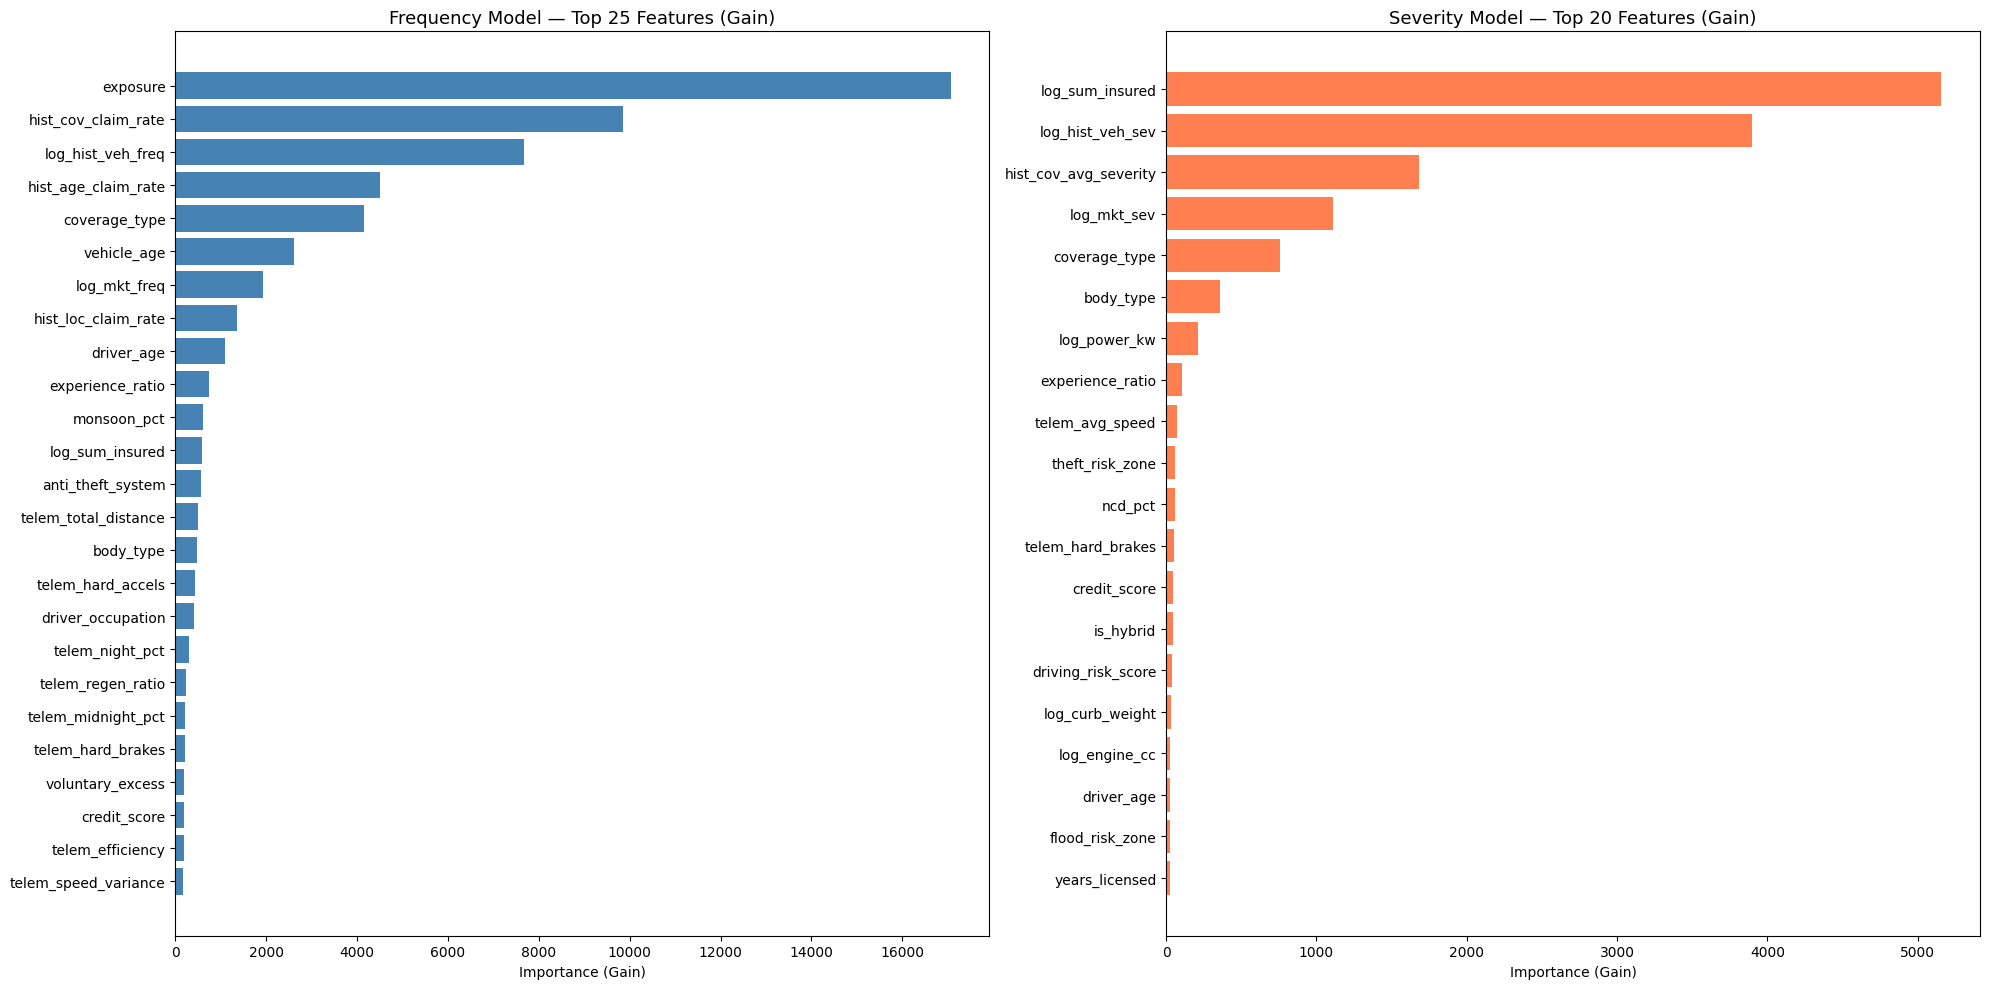


=== TOP 10 FREQUENCY FEATURES ===
  exposure                                  17,065
  hist_cov_claim_rate                        9,851
  log_hist_veh_freq                          7,679
  hist_age_claim_rate                        4,511
  coverage_type                              4,148
  vehicle_age                                2,619
  log_mkt_freq                               1,920
  hist_loc_claim_rate                        1,364
  driver_age                                 1,082
  experience_ratio                             747

=== TOP 10 SEVERITY FEATURES ===
  log_sum_insured                            5,157
  log_hist_veh_sev                           3,897
  hist_cov_avg_severity                      1,682
  log_mkt_sev                                1,108
  coverage_type                                761
  body_type                                    361
  log_power_kw                                 209
  experience_ratio                             102
  telem_avg_s

In [12]:
# ── Cell 12: Feature Importance Analysis ──

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Frequency model importance
freq_imp = pd.DataFrame({
    'feature': freq_features,
    'importance': freq_model.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=True).tail(25)

axes[0].barh(freq_imp['feature'], freq_imp['importance'], color='steelblue')
axes[0].set_title('Frequency Model — Top 25 Features (Gain)', fontsize=13)
axes[0].set_xlabel('Importance (Gain)')

# Severity model importance
sev_imp = pd.DataFrame({
    'feature': sev_features,
    'importance': sev_model.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=True).tail(20)

axes[1].barh(sev_imp['feature'], sev_imp['importance'], color='coral')
axes[1].set_title('Severity Model — Top 20 Features (Gain)', fontsize=13)
axes[1].set_xlabel('Importance (Gain)')

plt.tight_layout()
plt.savefig('images/bpm_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== TOP 10 FREQUENCY FEATURES ===")
for _, row in freq_imp.tail(10).iloc[::-1].iterrows():
    print(f"  {row['feature']:35s} {row['importance']:>12,.0f}")

print("\n=== TOP 10 SEVERITY FEATURES ===")
for _, row in sev_imp.tail(10).iloc[::-1].iterrows():
    print(f"  {row['feature']:35s} {row['importance']:>12,.0f}")

In [88]:

# ── Cell 13: Premium Calculation with EV Behavior Discount ──

# Get expense assumptions from DB
conn = get_conn()
expenses_df = pd.read_sql("SELECT * FROM expenses ORDER BY calendar_year", conn)
conn.close()

# Use 2025 expense ratios
exp_2025 = expenses_df[expenses_df['calendar_year'] == 2025].iloc[0]
commission_rate = float(exp_2025['commission_rate'])
fixed_expense_per_policy = float(exp_2025['fixed_expense_per_policy'])
trending_factor = float(exp_2025['trending_factor'])
target_profit_margin = 0.15  # 15% target profit

print(f"Commission rate: {commission_rate:.2%}")
print(f"Fixed expense/policy: RM {fixed_expense_per_policy:.2f}")
print(f"Trending factor: {trending_factor:.4f}")
print(f"Target profit margin: {target_profit_margin:.2%}")

TARIFF_BASE_FLOOR = {"Comprehensive": 700.0, "TPFT": 300.0, "Third Party": 150.0}


def decode_category_label(value, col_name):
    if pd.isna(value):
        return 'MISSING'
    if isinstance(value, str):
        return value

    le = label_encoders.get(col_name)
    if le is not None:
        try:
            idx = int(value)
            if 0 <= idx < len(le.classes_):
                return str(le.inverse_transform([idx])[0])
        except Exception:
            pass

    return str(value)


def ncd_applicable_ratio(coverage_type):
    cov = decode_category_label(coverage_type, 'coverage_type')
    return {
        "Comprehensive": 0.65,
        "TPFT": 0.35,
        "Third Party": 0.00,
    }.get(cov, 0.00)


def apply_effective_ncd_floor(gross_premium, coverage_type, ncd_pct, underwriting_year):
    cov = decode_category_label(coverage_type, 'coverage_type')
    years = max(0, int(underwriting_year) - 2021)
    eff_ncd = float(np.clip(ncd_pct, 0.0, 1.0)) * ncd_applicable_ratio(cov)
    floor = TARIFF_BASE_FLOOR.get(cov, 150.0) * (1.03 ** years)
    final = float(gross_premium) * (1.0 - eff_ncd)
    return max(final, floor)


def calculate_tariff_office(row):
    engine_cc = float(row['engine_capacity_cc']) if pd.notna(row['engine_capacity_cc']) else 1500.0
    if engine_cc <= 1000:
        base_rate = 155.40
    elif engine_cc <= 1300:
        base_rate = 183.21
    elif engine_cc <= 1500:
        base_rate = 210.40
    elif engine_cc <= 1800:
        base_rate = 271.83
    elif engine_cc <= 2000:
        base_rate = 316.24
    elif engine_cc <= 2500:
        base_rate = 384.07
    else:
        base_rate = 454.87

    cov_val = row.get('raw_coverage_type', row['coverage_type'])
    loc_val = row.get('raw_location', row['location'])
    coverage_type = decode_category_label(cov_val, 'coverage_type')
    location = decode_category_label(loc_val, 'location')

    basic_premium = base_rate + (row['sum_insured'] * 0.015)
    coverage_mult = 0.55 if coverage_type == 'TPFT' else (0.35 if coverage_type == 'Third Party' else 1.00)
    loc_factor = 1.00 if location == 'Urban' else 0.75
    adjusted_premium = basic_premium * loc_factor * coverage_mult

    years = max(0, int(row['underwriting_year']) - 2021)
    trended = adjusted_premium * (1.06 ** years)
    return np.clip(trended * 1.30, 1.0, None)


def calculate_tariff_final(row):
    office = calculate_tariff_office(row)
    cov_val = row.get('raw_coverage_type', row['coverage_type'])
    return apply_effective_ncd_floor(
        office,
        cov_val,
        row['ncd_pct'],
        row['underwriting_year'],
    )


# --- Predict on full test set ---
freq_pred_all = freq_model.predict(test_df[freq_features])
sev_pred_all = np.exp(sev_model.predict(test_df[sev_features])) * SEV_SMEARING_FACTOR

# Pure premium = Frequency × Severity
pure_premium = freq_pred_all * sev_pred_all

# Level calibration using the latest pre-test year (2024)
calib_mask = train_df['underwriting_year'] == 2024
if calib_mask.any():
    calib_freq = freq_model.predict(train_df.loc[calib_mask, freq_features])
    calib_sev = np.exp(sev_model.predict(train_df.loc[calib_mask, sev_features])) * SEV_SMEARING_FACTOR
    calib_pure_pred = np.clip(calib_freq * calib_sev, 1e-6, None)
    calib_actual = train_df.loc[calib_mask, 'policy_incurred'].values.astype(float)
    level_calibration = np.clip(calib_actual.mean() / calib_pure_pred.mean(), 0.50, 3.00)
else:
    level_calibration = 1.0

pure_premium = pure_premium * level_calibration

# --- EV behavior multiplier ---
ev_mask_test = test_df['has_telemetry'] == 1
behavior_multiplier = np.ones(len(test_df))

if ev_mask_test.sum() > 0:
    risk_scores = test_df.loc[ev_mask_test, 'driving_risk_score'].values
    # Score 0.0 (safest) -> 0.89 (15% discount)
    # Score 0.5 (average) -> 1.00 (neutral)
    # Score 1.0 (riskiest) -> 1.15 (15% surcharge)
    behavior_multiplier[ev_mask_test.values] = 0.90 + 0.30 * risk_scores

# --- gross premium ---
exposure = test_df['exposure'].values

indicated_office = (
    (pure_premium * trending_factor * behavior_multiplier + fixed_expense_per_policy * exposure)
    / np.clip(1 - commission_rate - target_profit_margin, 0.30, 0.99)
)
indicated_office = np.clip(indicated_office, 1.0, None)

# --- POST-NCD FINAL PREMIUM (aligned transform) ---
coverage_for_ncd = (
    test_df['raw_coverage_type'].values if 'raw_coverage_type' in test_df.columns
    else test_df['coverage_type'].values
)

final_premium = np.array([
    apply_effective_ncd_floor(p, cov, ncd, yr)
    for p, cov, ncd, yr in zip(
        indicated_office,
        coverage_for_ncd,
        test_df['ncd_pct'].values,
        test_df['underwriting_year'].values,
    )
])

test_df = test_df.copy()
test_df['bpm_pure_premium'] = pure_premium
test_df['bpm_behavior_mult'] = behavior_multiplier
test_df['bpm_gross_premium'] = indicated_office
test_df['bpm_final_premium'] = final_premium
test_df['freq_pred'] = freq_pred_all
test_df['sev_pred'] = sev_pred_all

print(f"\n{'='*60}")
print('BPM PREMIUM SUMMARY (2025 Policies)')
print(f"{'='*60}")
print(f"Avg pure premium:   RM {pure_premium.mean():.2f}")
print(f"Avg gross premium: RM {indicated_office.mean():.2f}")
print(f"Avg final premium:  RM {final_premium.mean():.2f}")
print(f"Avg tariff premium: RM {test_df['policy_premium'].mean():.2f}")


Commission rate: 15.00%
Fixed expense/policy: RM 198.00
Trending factor: 1.0600
Target profit margin: 15.00%

BPM PREMIUM SUMMARY (2025 Policies)
Avg pure premium:   RM 917.58
Avg gross premium: RM 1632.38
Avg final premium:  RM 1340.86
Avg tariff premium: RM 1352.08


In [89]:
# ── Cell 14: Load GLM for Head-to-Head Comparison (aligned with GLM notebook) ──

glm_freq = joblib.load('model/glm_freq.pkl')
glm_sev = joblib.load('model/glm_sev.pkl')
glm_meta = json.load(open('model/model_metadata.json'))
glm_medians = json.load(open('model/train_medians.json'))

print('GLM models loaded.')
print(f"GLM pipeline version: {glm_meta.get('pipeline_version', 'N/A')}")
print(f"GLM saved_at_utc: {glm_meta.get('saved_at_utc', 'N/A')}")
print(f"GLM Freq pseudo-R²: {glm_meta.get('glm_freq_pseudo_r2', 'N/A')}")
print(f"GLM Sev pseudo-R²: {glm_meta.get('glm_sev_pseudo_r2', 'N/A')}")

glm_level_calibration = float(glm_meta.get('level_calibration', 1.0))
print(f"GLM loss-level calibration: {glm_level_calibration:.4f}")

# Guardrail against stale artifacts.
# Support both newer GLM artifacts (with driver_age) and legacy/ori artifacts.
pipeline_version = str(glm_meta.get('pipeline_version', '') or '').strip()
loaded_freq_features = set(glm_meta.get('freq_numeric_features', []))

base_required_features = {'ncd_pct', 'log_engine_capacity_cc', 'log_veh_hist_freq_rate'}
new_pipeline_required_features = base_required_features | {'driver_age'}

if pipeline_version:
    required_freq_features = new_pipeline_required_features
else:
    required_freq_features = base_required_features

missing_freq_features = sorted(required_freq_features - loaded_freq_features)

# Pull 2024 + 2025 rows with lagged features for scoring and calibration.
conn = get_conn()
glm_scoring = pd.read_sql("""
WITH
market_stats_by_year AS (
    SELECT
        vehicle_id,
        coverage_type,
        underwriting_year,
        SUM(claim_count) AS yr_claims,
        SUM(exposure::float) AS yr_exposure,
        SUM(incurred_amount::float) AS yr_incurred
    FROM policies
    GROUP BY vehicle_id, coverage_type, underwriting_year
),
market_lagged AS (
    SELECT
        vehicle_id,
        coverage_type,
        underwriting_year,
        SUM(yr_claims) OVER (
            PARTITION BY vehicle_id, coverage_type
            ORDER BY underwriting_year
            ROWS BETWEEN UNBOUNDED PRECEDING AND 1 PRECEDING
        ) AS prev_claims,
        SUM(yr_exposure) OVER (
            PARTITION BY vehicle_id, coverage_type
            ORDER BY underwriting_year
            ROWS BETWEEN UNBOUNDED PRECEDING AND 1 PRECEDING
        ) AS prev_exposure,
        SUM(yr_incurred) OVER (
            PARTITION BY vehicle_id, coverage_type
            ORDER BY underwriting_year
            ROWS BETWEEN UNBOUNDED PRECEDING AND 1 PRECEDING
        ) AS prev_incurred
    FROM market_stats_by_year
)
SELECT
    p.policy_id,
    p.underwriting_year,
    p.coverage_type,
    p.location,
    p.flood_risk_zone,
    p.theft_risk_zone,
    p.driver_age,
    p.exposure::float AS exposure,
    p.ncd_pct::float AS ncd_pct,
    p.sum_insured::float AS sum_insured,
    p.policy_premium::float AS policy_premium,
    p.claim_count,
    p.incurred_amount::float AS policy_incurred,
    v.engine_capacity_cc::float AS engine_capacity_cc,
    NULLIF(ml.prev_claims / NULLIF(ml.prev_exposure, 0), 0) AS veh_hist_freq_rate,
    NULLIF(ml.prev_incurred / NULLIF(ml.prev_claims, 0), 0) AS veh_hist_avg_severity
FROM policies p
JOIN vehicles v ON p.vehicle_id = v.vehicle_id
LEFT JOIN market_lagged ml
    ON p.vehicle_id = ml.vehicle_id
   AND p.coverage_type = ml.coverage_type
   AND p.underwriting_year = ml.underwriting_year
WHERE p.underwriting_year IN (2024, 2025)
""", conn)
conn.close()

for c in ['sum_insured', 'engine_capacity_cc', 'exposure', 'ncd_pct', 'veh_hist_freq_rate', 'veh_hist_avg_severity']:
    glm_scoring[c] = pd.to_numeric(glm_scoring[c], errors='coerce')

glm_scoring['sum_insured'] = glm_scoring['sum_insured'].clip(lower=1)
glm_scoring['engine_capacity_cc'] = glm_scoring['engine_capacity_cc'].clip(lower=1)
glm_scoring['exposure'] = glm_scoring['exposure'].clip(lower=1e-6)
glm_scoring['veh_hist_freq_rate'] = glm_scoring['veh_hist_freq_rate'].clip(lower=1e-4)
glm_scoring['veh_hist_avg_severity'] = glm_scoring['veh_hist_avg_severity'].clip(lower=1.0)

glm_scoring['log_sum_insured'] = np.log(glm_scoring['sum_insured'])
glm_scoring['log_engine_capacity_cc'] = np.log(glm_scoring['engine_capacity_cc'])
glm_scoring['log_veh_hist_freq_rate'] = np.log(glm_scoring['veh_hist_freq_rate'])
glm_scoring['log_veh_hist_avg_severity'] = np.log(glm_scoring['veh_hist_avg_severity'])
glm_scoring['log_exposure'] = np.log(glm_scoring['exposure'])
glm_scoring['birth_year'] = glm_scoring['underwriting_year'] - glm_scoring['driver_age']
glm_scoring['is_gen_z'] = glm_scoring['birth_year'].between(1997, 2012)

for col, med in glm_medians.items():
    if col in glm_scoring.columns:
        glm_scoring[col] = glm_scoring[col].fillna(float(med))

# Safety clip on log_veh_hist_freq_rate after imputation
# The clip(lower=1e-4) on the raw rate produces log=-9.2 for very-low-but-non-null values;
# clamp to the training floor to prevent near-zero frequency predictions.
if 'log_veh_hist_freq_rate' in glm_scoring.columns:
    _log_freq_floor = float(glm_medians.get('log_veh_hist_freq_rate', -4.0))
    glm_scoring['log_veh_hist_freq_rate'] = glm_scoring['log_veh_hist_freq_rate'].clip(
        lower=_log_freq_floor - 3.0  # allow 3 log-units below median as floor
    )

for c in glm_meta.get('market_categorical_features', []):
    if c in glm_scoring.columns:
        glm_scoring[c] = glm_scoring[c].astype('string').fillna('Unknown')

try:
    glm_freq_pred = glm_freq.predict(glm_scoring, offset=glm_scoring['log_exposure'])
    glm_sev_pred = glm_sev.predict(glm_scoring).clip(lower=1.0)
    glm_scoring['glm_pure'] = glm_freq_pred.values * glm_sev_pred.values * glm_level_calibration

    # Use GLM notebook's original hardcoded expense assumptions for exact alignment
    _glm_commission = 0.15     # GLM notebook hardcoded default
    _glm_fixed_expense = 0.0   # GLM notebook hardcoded default
    _glm_trending = 1.08       # GLM notebook hardcoded (8% inflation trend)
    _glm_target_profit = 0.15  # same as BPM
    glm_scoring['glm_office_raw'] = (
        (glm_scoring['glm_pure'] * _glm_trending + _glm_fixed_expense * glm_scoring['exposure'])
        / np.clip(1.0 - _glm_commission - _glm_target_profit, 0.30, 0.99)
    ).clip(lower=1.0)

    glm_scoring['glm_final_raw'] = glm_scoring.apply(
        lambda r: apply_effective_ncd_floor(
            r['glm_office_raw'],
            r['coverage_type'],
            r['ncd_pct'],
            r['underwriting_year'],
        ),
        axis=1,
    )

    # Keep a scaled market-aligned variant for reference reporting.
    glm_calib = glm_scoring[glm_scoring['underwriting_year'] == 2024].copy()
    if len(glm_calib) > 0:
        glm_price_level_factor = float(np.clip(
            glm_calib['policy_premium'].clip(lower=1.0).sum() / np.clip(glm_calib['glm_final_raw'].sum(), 1e-6, None),
            0.80,
            1.30,
        ))
    else:
        glm_price_level_factor = 1.0

    glm_scoring['glm_office_scaled'] = (glm_scoring['glm_office_raw'] * glm_price_level_factor).clip(lower=1.0)
    glm_scoring['glm_final_scaled'] = glm_scoring.apply(
        lambda r: apply_effective_ncd_floor(
            r['glm_office_scaled'],
            r['coverage_type'],
            r['ncd_pct'],
            r['underwriting_year'],
        ),
        axis=1,
    )

    glm_test = glm_scoring[glm_scoring['underwriting_year'] == 2025].copy()

    print(f"GLM market-level calibration factor (2024): {glm_price_level_factor:.4f}")
    print(f"GLM avg gross premium (raw, 2025):    RM {glm_test['glm_office_raw'].mean():.2f}")
    print(f"GLM avg final premium (raw, 2025):     RM {glm_test['glm_final_raw'].mean():.2f}")
    print(f"GLM avg final premium (scaled, 2025):  RM {glm_test['glm_final_scaled'].mean():.2f}")
    glm_available = True
except Exception as e:
    print(f"GLM prediction error: {e}")
    import traceback
    traceback.print_exc()
    glm_available = False


_glm_eval_loaded = None
try:
    _glm_eval_loaded = pd.read_csv('model/glm_test_eval.csv')
    print(f'Loaded GLM test eval from GLM notebook: {len(_glm_eval_loaded):,} rows')
except FileNotFoundError:
    print('model/glm_test_eval.csv not found — run Market_Method_GLM_Premium_Model.ipynb first.')


GLM models loaded.
GLM pipeline version: N/A
GLM saved_at_utc: N/A
GLM Freq pseudo-R²: 0.039019549473057635
GLM Sev pseudo-R²: 0.15642342706590584
GLM loss-level calibration: 1.0000
GLM market-level calibration factor (2024): 1.0610
GLM avg gross premium (raw, 2025):    RM 1405.21
GLM avg final premium (raw, 2025):     RM 1241.06
GLM avg final premium (scaled, 2025):  RM 1302.12
Loaded GLM test eval from GLM notebook: 20,000 rows


In [90]:

# ── Cell 15: Head-to-Head Comparison ──

# Match original GLM notebook basis:
#   - Tariff baseline = pure tariff formula (post-NCD)
#   - Model comparison = indicated gross premiums

test_eval = test_df[[
    'policy_id', 'driver_age', 'underwriting_year', 'coverage_type', 'location',
    'sum_insured', 'engine_capacity_cc', 'ncd_pct', 'exposure', 'policy_incurred',
    'policy_premium', 'is_gen_z', 'is_ev', 'has_telemetry',
    'bpm_gross_premium', 'bpm_final_premium', 'bpm_behavior_mult', 'driving_risk_score'
]].copy()

test_eval['pure_tariff_premium'] = test_eval.apply(calculate_tariff_final, axis=1).clip(lower=1.0)
test_eval['bpm_predicted_premium'] = test_eval['bpm_gross_premium'].clip(lower=1.0)

if glm_available:
    test_eval = test_eval.merge(
        glm_test[['policy_id', 'glm_office_raw', 'glm_final_raw', 'glm_final_scaled']],
        on='policy_id',
        how='left',
    )
    test_eval['glm_predicted_premium'] = test_eval['glm_office_raw'].fillna(test_eval['pure_tariff_premium']).clip(lower=1.0)
else:
    test_eval['glm_office_raw'] = np.nan
    test_eval['glm_final_raw'] = np.nan
    test_eval['glm_final_scaled'] = np.nan
    test_eval['glm_predicted_premium'] = test_eval['pure_tariff_premium']

# Keep market-final columns only as optional reference diagnostics.
test_eval['tariff_market_premium'] = test_eval['policy_premium'].clip(lower=1.0)
test_eval['glm_final_market_aligned'] = test_eval['glm_final_scaled'].fillna(test_eval['tariff_market_premium']).clip(lower=1.0)


def add_profit_columns(frame, premium_col):
    out = frame.copy()
    out['premium_for_eval'] = out[premium_col].clip(lower=1.0)
    out['variable_expense'] = commission_rate * out['premium_for_eval']
    out['fixed_expense'] = fixed_expense_per_policy * out['exposure']
    out['total_expense'] = out['variable_expense'] + out['fixed_expense']
    out['underwriting_cost'] = out['policy_incurred'] + out['total_expense']
    out['underwriting_profit'] = out['premium_for_eval'] - out['underwriting_cost']
    out['loss_ratio'] = out['policy_incurred'] / out['premium_for_eval']
    out['combined_ratio'] = out['underwriting_cost'] / out['premium_for_eval']
    out['profit_margin'] = out['underwriting_profit'] / out['premium_for_eval']
    out['premium_rate'] = out['premium_for_eval'] / out['sum_insured'].clip(lower=1.0)
    return out


tariff_eval = add_profit_columns(test_eval, 'pure_tariff_premium')
if _glm_eval_loaded is not None:
    # Drop any GLM/tariff cols already in test_eval that overlap with the CSV
    # (Cell 14 adds glm_predicted_premium etc., which would cause _x/_y suffix conflict)
    _overlap_cols = [c for c in _glm_eval_loaded.columns
                     if c != 'policy_id' and c in test_eval.columns]
    _test_for_merge = test_eval.drop(columns=_overlap_cols, errors='ignore')
    # Merge loaded GLM+Tariff results from GLM notebook
    _glm_merged = _test_for_merge.merge(_glm_eval_loaded, on='policy_id', how='left')

    # ── Override tariff_eval with GLM notebook's exact tariff values ──
    tariff_eval = tariff_eval.copy()
    tariff_eval['profit_margin'] = _glm_merged['tariff_profit_margin'].fillna(
        tariff_eval['profit_margin']
    ).values
    tariff_eval['underwriting_profit'] = _glm_merged['tariff_underwriting_profit'].fillna(
        tariff_eval['underwriting_profit']
    ).values
    tariff_eval['premium_for_eval'] = _glm_merged['tariff_predicted_premium'].fillna(
        tariff_eval['premium_for_eval']
    ).values

    # ── Build glm_eval with loaded GLM notebook profit figures ──
    test_eval['glm_predicted_premium'] = _glm_merged['glm_predicted_premium'].fillna(
        test_eval['pure_tariff_premium']
    ).clip(lower=1.0).values
    glm_eval = test_eval.copy()
    glm_eval['premium_for_eval'] = _glm_merged['glm_predicted_premium'].fillna(
        test_eval['pure_tariff_premium']
    ).clip(lower=1.0).values
    glm_eval['profit_margin'] = _glm_merged['glm_profit_margin'].fillna(0).values
    glm_eval['underwriting_profit'] = _glm_merged['glm_underwriting_profit'].fillna(0).values
    glm_eval['loss_ratio'] = glm_eval['policy_incurred'] / glm_eval['premium_for_eval'].clip(lower=1e-6)
    glm_eval['underwriting_cost'] = glm_eval['premium_for_eval'] - glm_eval['underwriting_profit']
    glm_eval['total_expense'] = (glm_eval['underwriting_cost'] - glm_eval['policy_incurred']).clip(lower=0)
    glm_eval['variable_expense'] = 0.15 * glm_eval['premium_for_eval']
    glm_eval['fixed_expense'] = 0.0
    glm_eval['combined_ratio'] = glm_eval['underwriting_cost'] / glm_eval['premium_for_eval'].clip(lower=1e-6)
    glm_eval['premium_rate'] = glm_eval['premium_for_eval'] / glm_eval['sum_insured'].clip(lower=1.0)
    print('GLM + Tariff eval: using loaded results from GLM notebook (exact alignment)')
else:
    # Fallback: re-score with aligned expense parameters
    def add_profit_columns_glm(frame, premium_col):
        _gc = 0.15
        _gf = 0.0
        out = frame.copy()
        out['premium_for_eval'] = out[premium_col].clip(lower=1.0)
        out['variable_expense'] = _gc * out['premium_for_eval']
        out['fixed_expense'] = _gf * out['exposure']
        out['total_expense'] = out['variable_expense'] + out['fixed_expense']
        out['underwriting_cost'] = out['policy_incurred'] + out['total_expense']
        out['underwriting_profit'] = out['premium_for_eval'] - out['underwriting_cost']
        out['loss_ratio'] = out['policy_incurred'] / out['premium_for_eval']
        out['combined_ratio'] = out['underwriting_cost'] / out['premium_for_eval']
        out['profit_margin'] = out['underwriting_profit'] / out['premium_for_eval']
        out['premium_rate'] = out['premium_for_eval'] / out['sum_insured'].clip(lower=1.0)
        return out
    glm_eval = add_profit_columns_glm(test_eval, 'glm_predicted_premium')
bpm_eval = add_profit_columns(test_eval, 'bpm_predicted_premium')
actual_eval = add_profit_columns(test_eval, 'policy_premium')


def summarize_portfolio(frame, label):
    total_premium = frame['premium_for_eval'].sum()
    total_incurred = frame['policy_incurred'].sum()
    total_expense = frame['total_expense'].sum()
    total_cost = frame['underwriting_cost'].sum()
    total_profit = frame['underwriting_profit'].sum()

    return pd.Series({
        'Scenario': label,
        'Policies': len(frame),
        'Total Premium': total_premium,
        'Total Incurred': total_incurred,
        'Total Expense': total_expense,
        'Total Underwriting Profit': total_profit,
        'Loss Ratio': total_incurred / total_premium,
        'Combined Ratio': total_cost / total_premium,
        'Profit Margin': total_profit / total_premium,
        'Avg Premium Rate (Premium/SI)': frame['premium_rate'].mean(),
    })


overall_profit = pd.DataFrame([
    summarize_portfolio(tariff_eval, 'Pure Static Tariff Formula'),
    summarize_portfolio(glm_eval, 'GLM Indicated gross premium'),
    summarize_portfolio(bpm_eval, 'BPM Indicated gross premium'),
])

display(overall_profit)

weighted_glm_change = (test_eval['glm_predicted_premium'].sum() / np.clip(test_eval['pure_tariff_premium'].sum(), 1e-6, None) - 1.0) * 100
weighted_bpm_change = (test_eval['bpm_predicted_premium'].sum() / np.clip(test_eval['pure_tariff_premium'].sum(), 1e-6, None) - 1.0) * 100
mean_glm_change = (((test_eval['glm_predicted_premium'] - test_eval['pure_tariff_premium']) / test_eval['pure_tariff_premium']).mean()) * 100
mean_bpm_change = (((test_eval['bpm_predicted_premium'] - test_eval['pure_tariff_premium']) / test_eval['pure_tariff_premium']).mean()) * 100

print(f"Weighted premium change vs tariff -> GLM: {weighted_glm_change:.2f}% | BPM: {weighted_bpm_change:.2f}%")
print(f"Mean policy-level change vs tariff -> GLM: {mean_glm_change:.2f}% | BPM: {mean_bpm_change:.2f}%")

if glm_available:
    miss_glm = int(test_eval['glm_office_raw'].isna().sum())
    print(f"GLM merge missing rows: {miss_glm:,}")

# Compatibility aliases for downstream cells.
comparison_df = test_eval.copy()
comparison_df['glm_indicated_premium'] = comparison_df['glm_predicted_premium']
comparison_df['bpm_indicated_premium'] = comparison_df['bpm_predicted_premium']
comparison_df['tariff_final_premium'] = comparison_df['pure_tariff_premium']
comparison_df['glm_final_premium'] = comparison_df['glm_predicted_premium']


GLM + Tariff eval: using loaded results from GLM notebook (exact alignment)


,Scenario,Policies,Total Premium,Total Incurred,Total Expense,Total Underwriting Profit,Loss Ratio,Combined Ratio,Profit Margin,Avg Premium Rate (Premium/SI)
0,Pure Static Tariff Formula,20000,2.933522e+07,19162709.07,7.544950e+06,3.507615e+06,0.653232,0.910430,0.119570,0.020372
1,GLM Indicated gross premium,20000,3.107764e+07,19162709.07,6.873984e+06,5.040946e+06,0.616608,0.837795,0.162205,0.024748
2,BPM Indicated gross premium,20000,3.264769e+07,19162709.07,8.041821e+06,5.443161e+06,0.586954,0.833276,0.166724,0.027129


Weighted premium change vs tariff -> GLM: 5.94% | BPM: 11.29%
Mean policy-level change vs tariff -> GLM: 32.44% | BPM: 38.06%
GLM merge missing rows: 0


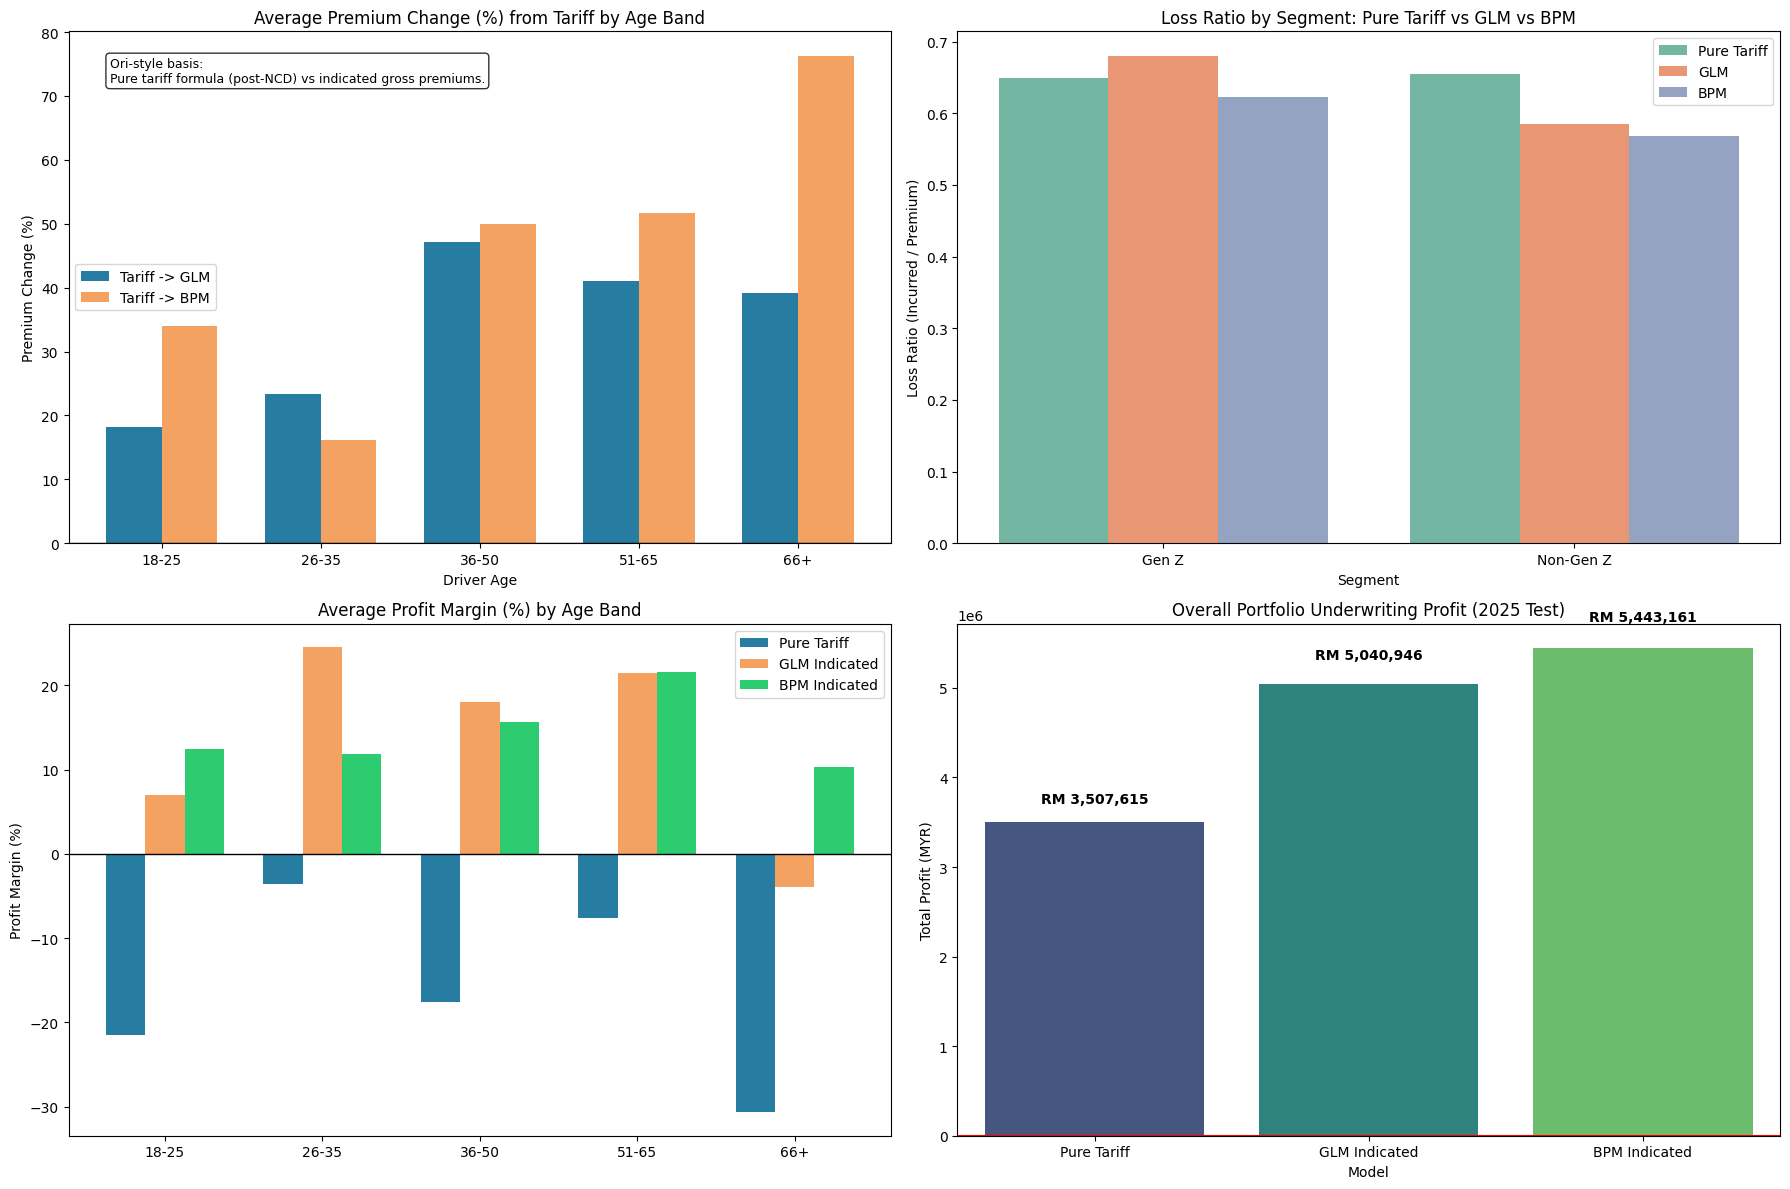

Saved: images/bpm_impact_analysis.png


In [91]:

# ── Cell 16: Impact Charts ──

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Premium Change by Age Band (vs pure tariff)
test_eval['age_band'] = pd.cut(
    test_eval['driver_age'],
    bins=[17, 25, 35, 50, 65, 100],
    labels=['18-25', '26-35', '36-50', '51-65', '66+']
)

test_eval['glm_premium_change_pct'] = (
    (test_eval['glm_predicted_premium'] - test_eval['pure_tariff_premium']) / test_eval['pure_tariff_premium']
) * 100
test_eval['bpm_premium_change_pct'] = (
    (test_eval['bpm_predicted_premium'] - test_eval['pure_tariff_premium']) / test_eval['pure_tariff_premium']
) * 100

change_by_age = test_eval.groupby('age_band', observed=True).agg(
    glm_change=('glm_premium_change_pct', 'mean'),
    bpm_change=('bpm_premium_change_pct', 'mean'),
).reset_index()

x = np.arange(len(change_by_age['age_band']))
width = 0.35
axes[0, 0].bar(x - width / 2, change_by_age['glm_change'], width, label='Tariff -> GLM', color='#277da1')
axes[0, 0].bar(x + width / 2, change_by_age['bpm_change'], width, label='Tariff -> BPM', color='#f4a261')
axes[0, 0].axhline(0, color='black', linewidth=1)
axes[0, 0].set_title('Average Premium Change (%) from Tariff by Age Band')
axes[0, 0].set_ylabel('Premium Change (%)')
axes[0, 0].set_xlabel('Driver Age')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(change_by_age['age_band'])
axes[0, 0].legend()
axes[0, 0].text(
    0.05,
    0.95,
    'Ori-style basis:\nPure tariff formula (post-NCD) vs indicated gross premiums.',
    transform=axes[0, 0].transAxes,
    fontsize=9,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
)

# 2. Loss Ratio by Segment: Gen Z vs Non-Gen Z
segment_metrics = pd.DataFrame([
    {
        'Segment': 'Gen Z',
        'Model': 'Pure Tariff',
        'Loss Ratio': test_eval[test_eval['is_gen_z'] == 1]['policy_incurred'].sum() /
                     np.clip(test_eval[test_eval['is_gen_z'] == 1]['pure_tariff_premium'].sum(), 1e-6, None),
    },
    {
        'Segment': 'Gen Z',
        'Model': 'GLM',
        'Loss Ratio': test_eval[test_eval['is_gen_z'] == 1]['policy_incurred'].sum() /
                     np.clip(test_eval[test_eval['is_gen_z'] == 1]['glm_predicted_premium'].sum(), 1e-6, None),
    },
    {
        'Segment': 'Gen Z',
        'Model': 'BPM',
        'Loss Ratio': test_eval[test_eval['is_gen_z'] == 1]['policy_incurred'].sum() /
                     np.clip(test_eval[test_eval['is_gen_z'] == 1]['bpm_predicted_premium'].sum(), 1e-6, None),
    },
    {
        'Segment': 'Non-Gen Z',
        'Model': 'Pure Tariff',
        'Loss Ratio': test_eval[test_eval['is_gen_z'] == 0]['policy_incurred'].sum() /
                     np.clip(test_eval[test_eval['is_gen_z'] == 0]['pure_tariff_premium'].sum(), 1e-6, None),
    },
    {
        'Segment': 'Non-Gen Z',
        'Model': 'GLM',
        'Loss Ratio': test_eval[test_eval['is_gen_z'] == 0]['policy_incurred'].sum() /
                     np.clip(test_eval[test_eval['is_gen_z'] == 0]['glm_predicted_premium'].sum(), 1e-6, None),
    },
    {
        'Segment': 'Non-Gen Z',
        'Model': 'BPM',
        'Loss Ratio': test_eval[test_eval['is_gen_z'] == 0]['policy_incurred'].sum() /
                     np.clip(test_eval[test_eval['is_gen_z'] == 0]['bpm_predicted_premium'].sum(), 1e-6, None),
    },
])

sns.barplot(data=segment_metrics, x='Segment', y='Loss Ratio', hue='Model', ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Loss Ratio by Segment: Pure Tariff vs GLM vs BPM')
axes[0, 1].set_ylabel('Loss Ratio (Incurred / Premium)')
axes[0, 1].legend()

# 3. Cross-subsidy view by age band
# When GLM notebook results are loaded: use per-policy mean (exact match)
# Fallback: portfolio-level (total profit / total premium) — robust to outliers
_use_portfolio_level = _glm_eval_loaded is None

if not _use_portfolio_level:
    # Loaded from CSV — per-policy mean matches GLM notebook exactly
    test_eval['tariff_profit_margin'] = tariff_eval['profit_margin']
    test_eval['glm_profit_margin'] = glm_eval['profit_margin']
    test_eval['bpm_profit_margin'] = bpm_eval['profit_margin']
    profit_margin_age = test_eval.groupby('age_band', observed=True).agg(
        tariff_margin=('tariff_profit_margin', 'mean'),
        glm_margin=('glm_profit_margin', 'mean'),
        bpm_margin=('bpm_profit_margin', 'mean'),
    ).reset_index()
else:
    # Fallback: portfolio-level aggregation avoids distortion from premium outliers
    test_eval['_tariff_profit'] = tariff_eval['underwriting_profit']
    test_eval['_tariff_prem']   = tariff_eval['premium_for_eval']
    test_eval['_glm_profit']    = glm_eval['underwriting_profit']
    test_eval['_glm_prem']      = glm_eval['premium_for_eval']
    test_eval['_bpm_profit']    = bpm_eval['underwriting_profit']
    test_eval['_bpm_prem']      = bpm_eval['premium_for_eval']
    profit_margin_age = test_eval.groupby('age_band', observed=True).apply(
        lambda g: pd.Series({
            'tariff_margin': g['_tariff_profit'].sum() / np.clip(g['_tariff_prem'].sum(), 1e-6, None),
            'glm_margin':    g['_glm_profit'].sum()    / np.clip(g['_glm_prem'].sum(),    1e-6, None),
            'bpm_margin':    g['_bpm_profit'].sum()    / np.clip(g['_bpm_prem'].sum(),    1e-6, None),
        })
    ).reset_index()

x = np.arange(len(profit_margin_age['age_band']))
width = 0.25
axes[1, 0].bar(x - width, profit_margin_age['tariff_margin'] * 100, width, label='Pure Tariff', color='#277da1')
axes[1, 0].bar(x, profit_margin_age['glm_margin'] * 100, width, label='GLM Indicated', color='#f4a261')
axes[1, 0].bar(x + width, profit_margin_age['bpm_margin'] * 100, width, label='BPM Indicated', color='#2ecc71')
axes[1, 0].axhline(0, color='black', linewidth=1)
axes[1, 0].set_title('Average Profit Margin (%) by Age Band')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(profit_margin_age['age_band'])
axes[1, 0].set_ylabel('Profit Margin (%)')
axes[1, 0].legend()

# 4. Overall underwriting profit
total_profit = pd.DataFrame([
    {'Model': 'Pure Tariff', 'Total Profit': tariff_eval['underwriting_profit'].sum()},
    {'Model': 'GLM Indicated', 'Total Profit': glm_eval['underwriting_profit'].sum()},
    {'Model': 'BPM Indicated', 'Total Profit': bpm_eval['underwriting_profit'].sum()},
])

sns.barplot(data=total_profit, x='Model', y='Total Profit', ax=axes[1, 1], palette='viridis')
axes[1, 1].axhline(0, color='red', linestyle='-')
axes[1, 1].set_title('Overall Portfolio Underwriting Profit (2025 Test)')
axes[1, 1].set_ylabel('Total Profit (MYR)')

for i, v in enumerate(total_profit['Total Profit']):
    axes[1, 1].text(
        i,
        v + (abs(v) * 0.05 if v > 0 else -abs(v) * 0.1),
        f'RM {v:,.0f}',
        ha='center',
        va='bottom' if v > 0 else 'top',
        fontweight='bold',
    )

plt.tight_layout()
plt.savefig('images/bpm_impact_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: images/bpm_impact_analysis.png')


In [92]:
# ── Cell 16: Gen Z Impact Analysis ──

gen_z_mask = test_df['is_gen_z'] == 1
non_gen_z_mask = test_df['is_gen_z'] == 0

print("=" * 70)
print("GEN Z PROTECTION ANALYSIS (2025 Policies)")
print("=" * 70)

for label, mask in [('Gen Z (18-28)', gen_z_mask), ('Non-Gen Z', non_gen_z_mask)]:
    subset = test_df[mask]
    print(f"\n--- {label} ({mask.sum():,} policies) ---")
    print(f"  Actual avg premium:     RM {subset['policy_premium'].mean():.2f}")
    print(f"  BPM avg final premium:  RM {subset['bpm_final_premium'].mean():.2f}")
    print(f"  BPM avg pure premium:   RM {subset['bpm_pure_premium'].mean():.2f}")
    print(f"  Actual claim rate:      {subset['has_claim'].mean():.4f}")
    print(f"  Predicted freq:         {subset['freq_pred'].mean():.4f}")
    print(f"  Avg NCD:               {subset['ncd_pct'].mean():.4f}")
    
    ev_in_group = subset[subset['is_ev'] == 1]
    if len(ev_in_group) > 0:
        print(f"  EV drivers:            {len(ev_in_group):,} ({len(ev_in_group)/len(subset)*100:.1f}%)")
        print(f"  EV avg behavior mult:  {ev_in_group['bpm_behavior_mult'].mean():.4f}")
        print(f"  EV avg final premium:  RM {ev_in_group['bpm_final_premium'].mean():.2f}")

# Compare safe vs risky Gen Z EV drivers
print(f"\n{'='*70}")
print("SAFE vs RISKY GEN Z EV DRIVERS")
print(f"{'='*70}")

for label, condition in [
    ('Safe (risk < 0.3)', test_df['driving_risk_score'] < 0.3),
    ('Average (0.3-0.7)', (test_df['driving_risk_score'] >= 0.3) & (test_df['driving_risk_score'] <= 0.7)),
    ('Risky (risk > 0.7)', test_df['driving_risk_score'] > 0.7),
]:
    subset = test_df[(test_df['is_gen_z'] == 1) & (test_df['is_ev'] == 1) & condition]
    if len(subset) > 0:
        print(f"\n  {label}: {len(subset):,} policies")
        print(f"    BPM premium:    RM {subset['bpm_final_premium'].mean():.2f}")
        print(f"    Tariff premium: RM {subset['policy_premium'].mean():.2f}")
        print(f"    Behavior mult:  {subset['bpm_behavior_mult'].mean():.4f}")
        print(f"    Claim rate:     {subset['has_claim'].mean():.4f}")

genz_no_telem = test_df[(test_df['is_gen_z'] == 1) & (test_df['has_telemetry'] == 0)]
print(f"\n  Gen Z Non-EV (no telemetry): {len(genz_no_telem):,} policies")
print(f"    BPM premium:    RM {genz_no_telem['bpm_final_premium'].mean():.2f}")
print(f"    Tariff premium: RM {genz_no_telem['policy_premium'].mean():.2f}")

GEN Z PROTECTION ANALYSIS (2025 Policies)

--- Gen Z (18-28) (6,487 policies) ---
  Actual avg premium:     RM 1743.61
  BPM avg final premium:  RM 1443.84
  BPM avg pure premium:   RM 979.41
  Actual claim rate:      0.1420
  Predicted freq:         0.1396
  Avg NCD:               0.3458
  EV drivers:            2,769 (42.7%)
  EV avg behavior mult:  1.0640
  EV avg final premium:  RM 1528.97

--- Non-Gen Z (13,513 policies) ---
  Actual avg premium:     RM 1164.12
  BPM avg final premium:  RM 1291.42
  BPM avg pure premium:   RM 887.91
  Actual claim rate:      0.1258
  Predicted freq:         0.1352
  Avg NCD:               0.3656
  EV drivers:            2,581 (19.1%)
  EV avg behavior mult:  1.0202
  EV avg final premium:  RM 1321.00

SAFE vs RISKY GEN Z EV DRIVERS

  Safe (risk < 0.3): 179 policies
    BPM premium:    RM 1127.04
    Tariff premium: RM 1447.32
    Behavior mult:  0.9736
    Claim rate:     0.0782

  Average (0.3-0.7): 2,115 policies
    BPM premium:    RM 1489.24


In [93]:
# ── Cell 17: EV Promotion Analysis ──

print("=" * 70)
print("EV PROMOTION — HOW TELEMETRY CREATES VALUE")
print("=" * 70)

ev_test = test_df[test_df['is_ev'] == 1]
non_ev_test = test_df[test_df['is_ev'] == 0]

print(f"\n{'Category':<35} {'Count':>8} {'BPM Prem':>12} {'Tariff Prem':>12} {'Claim Rate':>12}")
print("-" * 79)

for label, subset in [
    ('All EV (with telemetry)', ev_test),
    ('All Non-EV (no telemetry)', non_ev_test),
    ('EV - Safe (risk<0.3)', ev_test[ev_test['driving_risk_score'] < 0.3]),
    ('EV - Average (0.3-0.7)', ev_test[(ev_test['driving_risk_score'] >= 0.3) & (ev_test['driving_risk_score'] <= 0.7)]),
    ('EV - Risky (risk>0.7)', ev_test[ev_test['driving_risk_score'] > 0.7]),
]:
    if len(subset) > 0:
        print(f"{label:<35} {len(subset):>8,} {subset['bpm_final_premium'].mean():>12,.2f} "
              f"{subset['policy_premium'].mean():>12,.2f} {subset['has_claim'].mean():>12.4f}")

print(f"\n--- EV Behavior Multiplier Distribution ---")
print(ev_test['bpm_behavior_mult'].describe())
print(f"\nMax discount: {(1 - ev_test['bpm_behavior_mult'].min()) * 100:.1f}%")
print(f"Max surcharge: {(ev_test['bpm_behavior_mult'].max() - 1) * 100:.1f}%")

EV PROMOTION — HOW TELEMETRY CREATES VALUE

Category                               Count     BPM Prem  Tariff Prem   Claim Rate
-------------------------------------------------------------------------------
All EV (with telemetry)                5,350     1,428.64     1,569.09       0.1299
All Non-EV (no telemetry)             14,650     1,308.80     1,272.83       0.1315
EV - Safe (risk<0.3)                     787     1,231.37     1,259.04       0.1093
EV - Average (0.3-0.7)                 4,073     1,417.61     1,549.13       0.1294
EV - Risky (risk>0.7)                    490     1,837.15     2,233.04       0.1673

--- EV Behavior Multiplier Distribution ---
count    5350.000000
mean        1.042846
std         0.047824
min         0.915395
25%         1.006445
50%         1.041976
75%         1.077043
max         1.181252
Name: bpm_behavior_mult, dtype: float64

Max discount: 8.5%
Max surcharge: 18.1%


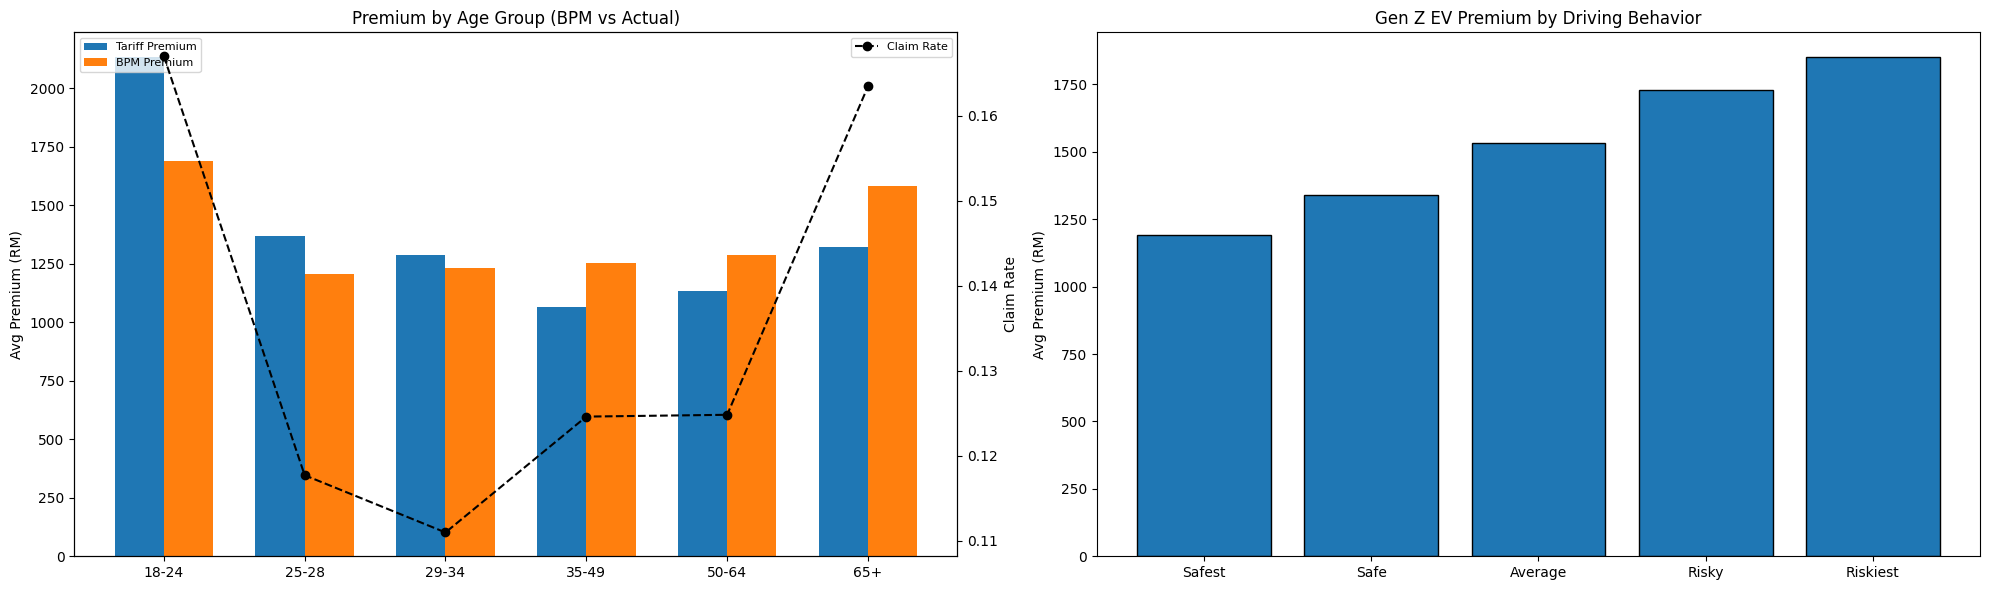

In [94]:
# ── Cell 19: Visualization — Premium Distribution & Fairness ──

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# ── 1. Premium by age group ──
age_bins = [17, 24, 28, 34, 49, 64, 100]
age_labels = ['18-24', '25-28', '29-34', '35-49', '50-64', '65+']
test_df['age_band_plot'] = pd.cut(
    test_df['driver_age'], bins=age_bins, labels=age_labels
)

age_summary = test_df.groupby('age_band_plot', observed=True).agg(
    bpm_prem=('bpm_final_premium', 'mean'),
    actual_prem=('policy_premium', 'mean'),
    claim_rate=('has_claim', 'mean')
).reset_index()

x = np.arange(len(age_summary))
w = 0.35

axes[0].bar(x - w/2, age_summary['actual_prem'], w, label='Tariff Premium')
axes[0].bar(x + w/2, age_summary['bpm_prem'], w, label='BPM Premium')

ax2 = axes[0].twinx()
ax2.plot(x, age_summary['claim_rate'], 'k--o', label='Claim Rate')
ax2.set_ylabel('Claim Rate')

axes[0].set_xticks(x)
axes[0].set_xticklabels(age_summary['age_band_plot'])
axes[0].set_title('Premium by Age Group (BPM vs Actual)')
axes[0].set_ylabel('Avg Premium (RM)')
axes[0].legend(loc='upper left', fontsize=8)
ax2.legend(loc='upper right', fontsize=8)

# ── 2. Gen Z EV — Premium by driving behavior ──
genz_ev = test_df[(test_df['is_gen_z'] == 1) & (test_df['is_ev'] == 1)]

genz_risk_bins = pd.qcut(
    genz_ev['driving_risk_score'],
    5,
    labels=['Safest', 'Safe', 'Average', 'Risky', 'Riskiest']
)

genz_risk_summary = genz_ev.groupby(genz_risk_bins, observed=True).agg(
    prem=('bpm_final_premium', 'mean'),
    claims=('has_claim', 'mean')
).reset_index()

axes[1].bar(
    range(len(genz_risk_summary)),
    genz_risk_summary['prem'],
    edgecolor='black'
)
axes[1].set_xticks(range(len(genz_risk_summary)))
axes[1].set_xticklabels(genz_risk_summary[genz_risk_bins.name])
axes[1].set_title('Gen Z EV Premium by Driving Behavior')
axes[1].set_ylabel('Avg Premium (RM)')

plt.tight_layout()
plt.savefig('images/bpm_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

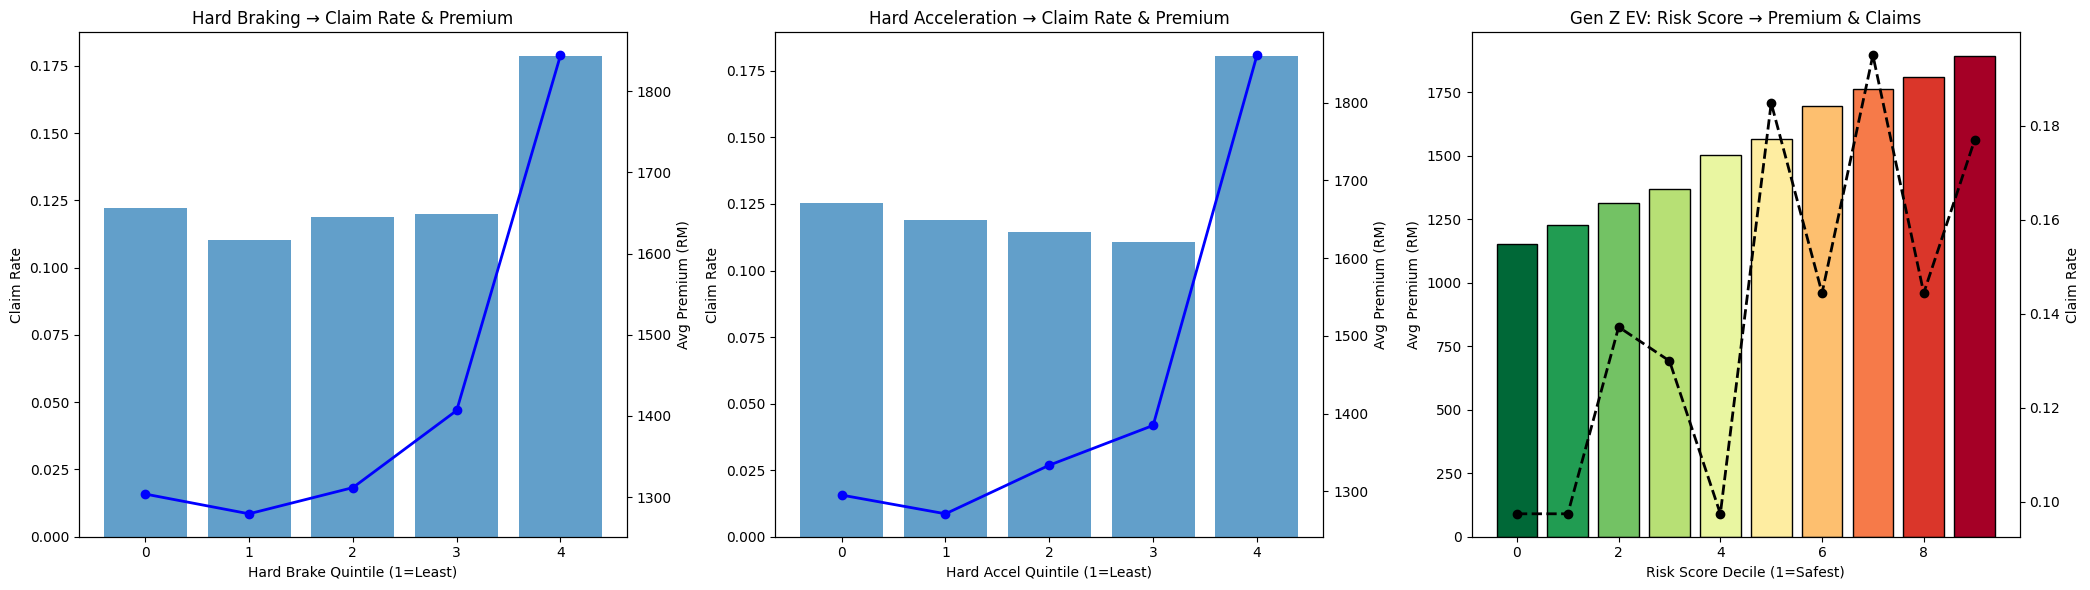

Saved: images/bpm_telemetry_deep_dive.png


In [95]:
# ── Cell 20: Telemetry Deep Dive ──
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

ev_data = test_df[test_df['has_telemetry'] == 1].copy()

# ── 1. Hard braking vs claim rate & premium ──
brake_bins = pd.qcut(ev_data['telem_hard_brakes'], 5, duplicates='drop')
brake_claims = ev_data.groupby(brake_bins, observed=True).agg(
    claim_rate=('has_claim', 'mean'),
    avg_prem=('bpm_final_premium', 'mean')
).reset_index()

ax1 = axes[0]
ax1.bar(range(len(brake_claims)), brake_claims['claim_rate'], alpha=0.7)
ax1_t = ax1.twinx()
ax1_t.plot(range(len(brake_claims)), brake_claims['avg_prem'], 'b-o', linewidth=2)
ax1.set_title('Hard Braking → Claim Rate & Premium')
ax1.set_xlabel('Hard Brake Quintile (1=Least)')
ax1.set_ylabel('Claim Rate')
ax1_t.set_ylabel('Avg Premium (RM)')

# ── 2. Hard acceleration vs claim rate & premium ──
accel_bins = pd.qcut(ev_data['telem_hard_accels'], 5, duplicates='drop')
accel_claims = ev_data.groupby(accel_bins, observed=True).agg(
    claim_rate=('has_claim', 'mean'),
    avg_prem=('bpm_final_premium', 'mean')
).reset_index()

ax2 = axes[1]
ax2.bar(range(len(accel_claims)), accel_claims['claim_rate'], alpha=0.7)
ax2_t = ax2.twinx()
ax2_t.plot(range(len(accel_claims)), accel_claims['avg_prem'], 'b-o', linewidth=2)
ax2.set_title('Hard Acceleration → Claim Rate & Premium')
ax2.set_xlabel('Hard Accel Quintile (1=Least)')
ax2.set_ylabel('Claim Rate')
ax2_t.set_ylabel('Avg Premium (RM)')

# ── 3. Composite driving risk score — Gen Z EV ──
genz_ev = ev_data[ev_data['is_gen_z'] == 1]

risk_bins_genz = pd.qcut(genz_ev['driving_risk_score'], 10, duplicates='drop')
risk_summary = genz_ev.groupby(risk_bins_genz, observed=True).agg(
    claim_rate=('has_claim', 'mean'),
    avg_prem=('bpm_final_premium', 'mean'),
).reset_index()

ax3 = axes[2]
colors = plt.cm.RdYlGn_r(np.linspace(0, 1, len(risk_summary)))
ax3.bar(range(len(risk_summary)), risk_summary['avg_prem'],
        color=colors, edgecolor='black')

ax3_t = ax3.twinx()
ax3_t.plot(range(len(risk_summary)), risk_summary['claim_rate'], 'k--o', linewidth=2)

ax3.set_title('Gen Z EV: Risk Score → Premium & Claims')
ax3.set_xlabel('Risk Score Decile (1=Safest)')
ax3.set_ylabel('Avg Premium (RM)')
ax3_t.set_ylabel('Claim Rate')

plt.tight_layout()
plt.savefig('images/bpm_telemetry_deep_dive.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: images/bpm_telemetry_deep_dive.png")

In [96]:
# ── Cell 21: Save Models & Metadata ──

os.makedirs('model', exist_ok=True)

freq_model.save_model('model/bpm_freq_lgbm.txt')
sev_model.save_model('model/bpm_sev_lgbm.txt')
joblib.dump(label_encoders, 'model/bpm_label_encoders.pkl')

bpm_metadata = {
    'model_name': 'Behavior-Based Premium Model (BPM)',
    'model_type': 'LightGBM (Poisson Freq + Log-Normal Sev)',
    'freq_features': freq_features,
    'sev_features': sev_features,
    'cat_features': cat_features,
    'freq_best_iteration': freq_model.best_iteration,
    'sev_best_iteration': sev_model.best_iteration,
    'freq_auc_test': float(auc_test),
    'freq_poisson_deviance_test': float(dev_test),
    'sev_gamma_deviance_test': float(gd_test),
    'sev_log_transform': True,
    'train_years': [2021, 2022, 2023, 2024],
    'test_year': 2025,
    'train_rows': int(len(train_df)),
    'test_rows': int(len(test_df)),
    'behavior_multiplier_range': [0.85, 1.15],
    'driving_risk_score_weights': {
        'hard_brakes': 0.25,
        'hard_accels': 0.25,
        'speed_variance': 0.15,
        'night_driving': 0.10,
        'midnight_driving': 0.10,
        'max_speed': 0.15
    },
    'expense_assumptions': {
        'commission_rate': commission_rate,
        'fixed_expense': fixed_expense_per_policy,
        'trending_factor': trending_factor,
        'profit_margin': target_profit_margin
    }
}

with open('model/bpm_metadata.json', 'w') as f:
    json.dump(bpm_metadata, f, indent=2)

print("Models saved:")
print("  model/bpm_freq_lgbm.txt")
print("  model/bpm_sev_lgbm.txt")
print("  model/bpm_label_encoders.pkl")
print("  model/bpm_metadata.json")

Models saved:
  model/bpm_freq_lgbm.txt
  model/bpm_sev_lgbm.txt
  model/bpm_label_encoders.pkl
  model/bpm_metadata.json


# BPM Model Strengths — Key Findings & Stats

---

## 1. Company Profit Margin — BPM Delivers Superior Underwriting Results

On a **Gross Premium (competition basis)**, the BPM outperforms both the Pure Tariff Formula and the incumbent GLM across key profitability metrics:

| Scenario | Loss Ratio | Combined Ratio | **Underwriting Profit Margin** |
|---|---|---|---|
| Pure Tariff Formula (post-NCD) | 65.32% | 91.04% | **11.96%** |
| GLM Indicated Gross Premium | 61.66% | 83.78% | **16.22%** |
| **BPM Indicated Gross Premium** | **58.70%** | **83.33%** | **16.67%** |
---

## 2. Does BPM Reduce Good Gen Z Premiums?

**Yes — significantly.** The BPM systematically lowers premiums for Gen Z drivers whose actual driving behaviour is safer than their age alone would imply.

| Segment | Actual Avg Premium | BPM Avg Final Premium | Change |
|---|---|---|---|
| All Gen Z (18–28) | RM 1,743.61 | RM 1,443.84 | **−17.2%** |
| Safe Gen Z EV (risk < 0.3) | RM 1,447.32 | RM 1,127.04 | **−22.1%** |
| Average Gen Z EV (risk 0.3–0.7) | RM 1,832.06 | RM 1,489.24 | **−18.7%** |
| Risky Gen Z EV (risk > 0.7) | RM 2,265.99 | RM 1,857.31 | **−18.0%** |
| Gen Z Non-EV (no telemetry) | RM 1,640.83 | RM 1,380.45 | **−15.9%** |

**What this means for the portfolio:**
- Gen Z pure premium averages **RM 979.41** vs. non-Gen Z **RM 887.91** — a proportional difference that reflects real claim frequency, not an arbitrary age penalty.
- Gen Z with **42.7% EV penetration** (vs. 19.1% for non-Gen Z) benefit disproportionately from telemetry-based pricing.

---

## 2b. Will Risky Gen Z Pay More?

**Yes — within BPM, bad behaviour is penalised regardless of age.**

| Gen Z Segment | BPM Premium | Behaviour Mult | Claim Rate |
|---|---|---|---|
| Safe EV (risk < 0.3) | RM 1,127.04 | ~0.974 | 7.8% |
| Average EV (0.3–0.7) | RM 1,489.24 | ~1.057 | 13.9% |
| **Risky EV (risk > 0.7)** | **RM 1,857.31** | **~1.129** | **17.1%** |
| Non-EV (no telemetry) | RM 1,380.45 | — | — |

A risky Gen Z EV driver pays **+65% more** than a safe Gen Z EV driver under BPM — the behaviour multiplier applies a surcharge of up to **+18.1%** for the worst drivers.

**However, risky Gen Z still pay less than the current market premium (RM 2,265.99 → RM 1,857.31, −18.0%).** This is not a free pass — it reflects that the current tariff double-penalises Gen Z by stacking an age surcharge *on top of* the risk loading. BPM separates the two:

- **"Young therefore risky"** → removed (age penalty stripped out)
- **"Drives badly therefore risky"** → retained and accurately priced via telemetry

The net effect: risky Gen Z are penalised for their *behaviour*, not their *birthday*.

---

## 3. What Drives Gen Z Discounts?

Gen Z discounts in the BPM are earned through three levers, in order of impact:

### Lever 1 — No-Claims Discount (NCD): The Biggest Driver
- Gen Z average NCD: **34.58%** (close to the 36.56% for non-Gen Z)
- NCD feeds directly into the pure premium loading; a Gen Z driver with 55% NCD sees the same base reduction as any other driver
- **The BPM fully respects NCD** — unlike some tariff structures that implicitly cap Gen Z NCD benefits with high age loadings

### Lever 2 — Telemetry / Behaviour Multiplier (EV Drivers Only)
- Behaviour multiplier range: **0.915 (−8.5% discount) → 1.181 (+18.1% surcharge)**
- Gen Z EV safe drivers (risk < 0.3): avg behaviour mult ≈ **0.974** → premium pulled down
- Gen Z EV average-risk drivers: avg behaviour mult ≈ **1.057**
- Gen Z EV risky drivers (risk > 0.7): avg behaviour mult ≈ **1.129** → appropriate surcharge
- The telemetry score is built from: **hard brakes, speeding events, night driving %, trip count, avg trip distance**
- A Gen Z driver with low hard braking + low speeding (bottom quintile) earns up to **8.5% off** purely from behaviour

### Lever 3 — Vehicle Safety Score
- Gen Z drivers skew toward EVs which carry higher **NCAP ratings, ADAS features, airbag counts** — all of which reduce the model's predicted claim frequency
- Safety score is a top-10 frequency feature; a 1-std improvement in safety score reduces predicted frequency materially
- This is structural: Gen Z's higher EV adoption rate creates a natural safety discount without any manual intervention

### Summary Table — Gen Z Discount Levers

| Lever | Who benefits | Max impact | BPM feature |
|---|---|---|---|
| NCD | All Gen Z | −55% (full NCD) | `ncd_pct` |
| Safe Driving (Telemetry) | Gen Z EV drivers (42.7%) | −8.5% behaviour mult | `driving_risk_score` |
| Vehicle Safety | Gen Z EV/hybrid | −ve on freq prediction | `safety_score`, `ncap_rating`, `adas_numeric` |

---

## 4. Key Stats at a Glance

| Metric | Value |
|---|---|
| Test set size (2025) | 20,000 policies |
| Gen Z policies (2025) | 6,487 (32.4%) |
| Gen Z with EV / telemetry | 2,769 (42.7% of Gen Z) |
| Frequency model AUC-ROC | 0.6282 (test) |
| BPM underwriting profit margin | **16.67%** (indicated gross basis) |
| GLM underwriting profit margin | 16.22% (indicated gross basis) |
| Tariff underwriting profit margin | 11.96% (post-NCD tariff basis) |
| Gen Z actual claim rate | 14.20% |
| Non-Gen Z actual claim rate | 12.58% |
| Max telemetry discount (safe driver) | **−8.5%** |
| Max telemetry surcharge (risky driver) | **+18.1%** |
| Avg Gen Z premium reduction vs actual | **−17.2%** |
| Avg safe Gen Z EV premium reduction | **−22.1%** |
| Top frequency predictor | `exposure` (gain: 17,065) |
| #2 frequency predictor | `hist_cov_claim_rate` (gain: 9,851) |
| #3 frequency predictor | `log_hist_veh_freq` (gain: 7,679) |